# Pigmentation CNN x AlphaGenome variant scoring

This notebook combines the trained `CNN2` pigmentation classifier
(`configs/predictors/genotype_based/pigmentation/pigmentation_binary.yaml`) with live
AlphaGenome API predictions and the GRCh38 reference genome to:

1. Survey every variant inside each pigmentation gene's real 512 kbp (524,288 bp) training
   window (`1kg_high_coverage` dataset).
2. Explore AlphaGenome's full track catalog and pick a broader signal set (ATAC, DNase, CAGE,
   ChIP, splice sites) to build a cheap variant-relevance heuristic -- the CNN itself only ever
   sees `rna_seq`, so the extra tracks are used purely to *rank* variants before the expensive
   stage.
3. Run the true ALT allele of the top-ranked variants through AlphaGenome (`predict_variant`)
   and the trained CNN, aligned onto the same `bcftools_chain` coordinate axis used at training
   time, to rerank variants by their actual effect on the model's logits.

**Design choices made explicit up front:**

- The CNN-effect score in Section 8 compares a *synthetic pure-reference individual* (no
  variants anywhere, built from AlphaGenome's reference-only predictions) against the same
  individual with exactly one variant injected. This isolates a single variant's effect,
  uncontaminated by any real person's other genotypes, and matches the task's literal framing:
  "the human reference genome modified by the variant".
- Top-k defaults to 25 variants (global, across all 11 genes) for the expensive
  `predict_variant` + CNN stage.


In [74]:
import os
import sys
import json
import pickle
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path("/home/breno/I2CA/genomics")
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.chdir(REPO_ROOT)

In [ ]:
from genomics.predictors.genotype_based.config import (
    load_config,
    generate_experiment_name,
    get_experiment_runs_dir,
    get_dataset_cache_dir,
)
from genomics.core.data_registry import resolve_dataset

# Importing the alphagenome client module itself needs no API key -- only `dna_client.create()`
# (Section "AlphaGenome client" below) does. Imported here so constants like
# `dna_client.SEQUENCE_LENGTH_500KB` are available to Section 1 without requiring the key yet.
from alphagenome.data import genome
from alphagenome.models import dna_client

CONFIG_PATH = REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary.yaml"
config = load_config(CONFIG_PATH)

DATASET_DIR = resolve_dataset(config.dataset_input.dataset_id).path
GENES = list(config.dataset_input.genes_to_use)
ONTOLOGY_TERMS = list(config.dataset_input.ontology_terms)
WINDOW_CENTER_SIZE = config.dataset_input.window_center_size

print(f"Dataset dir       : {DATASET_DIR}")
print(f"Genes ({len(GENES)})       : {GENES}")
print(f"Ontology terms    : {ONTOLOGY_TERMS}")
print(f"window_center_size: {WINDOW_CENTER_SIZE}")
print(f"alphagenome_outputs (CNN input): {config.dataset_input.alphagenome_outputs}")
print(f"known_classes     : {config.output.known_classes}")

Dataset dir       : /dados/GENOMICS_DATA/v1/1kG_high_coverage
Genes (11)       : ['MC1R', 'TYRP1', 'TYR', 'SLC45A2', 'DDB1', 'EDAR', 'MFSD12', 'OCA2', 'HERC2', 'SLC24A5', 'TCHH']
Ontology terms    : ['CL:1000458', 'CL:0000346', 'CL:2000092']
window_center_size: 32768
alphagenome_outputs (CNN input): ['rna_seq']
known_classes     : ['strong pigmentation', 'weak pigmentation']


In [76]:
from dotenv import load_dotenv

# Picks up ALPHAGENOME_API_KEY from either the shell environment or ~/.env (this repo's
# convention for storing API keys outside of chat/context -- see the `credentials` skill).
load_dotenv(Path.home() / ".env")
API_KEY = os.environ.get("ALPHAGENOME_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "ALPHAGENOME_API_KEY not found in the environment or ~/.env. "
        "Get a key at https://www.alphagenomedocs.com/ and add it with:\n"
        '  printf "Enter ALPHAGENOME_API_KEY (typing hidden): " && read -s val && echo '
        '&& echo "ALPHAGENOME_API_KEY=$val" >> ~/.env'
    )

client = dna_client.create(api_key=API_KEY)
ORGANISM = dna_client.Organism.HOMO_SAPIENS
print("AlphaGenome client ready.")

AlphaGenome client ready.


## Section 1 -- Config, dataset & window discovery

For each gene, `references/windows/<GENE>/window_metadata.json` is the authoritative record of
the exact 512 kbp (524,288 bp) window materialized during dataset generation -- this is what we
use below, rather than recomputing the window from the GTF ourselves.

In [77]:
def load_window_metadata(gene: str) -> dict:
    path = DATASET_DIR / "references" / "windows" / gene / "window_metadata.json"
    with open(path) as f:
        return json.load(f)


windows = {gene: load_window_metadata(gene) for gene in GENES}


def window_row(gene: str, w: dict) -> dict:
    start = int(w["start"])
    # window_metadata.json's own "end" is 1 bp short of `start + 524288` (an inclusive-style
    # convention, verified empirically against references/windows/<GENE>/ref.window.fa, which is
    # always exactly 524,288 bp long) -- so the true half-open end is computed directly instead
    # of trusted from the JSON, guaranteeing a valid AlphaGenome SEQUENCE_LENGTH_500KB interval.
    end = start + dna_client.SEQUENCE_LENGTH_500KB
    return {
        "gene": gene,
        "chrom": w["chromosome"],
        "start": start,
        "end": end,
        "window_size": end - start,
        "vcf_path": w.get("raw_variant_source", {}).get("vcf_path"),
    }


windows_df = pd.DataFrame([window_row(g, w) for g, w in windows.items()]).sort_values("gene").reset_index(drop=True)
assert (windows_df["window_size"] == dna_client.SEQUENCE_LENGTH_500KB).all()
windows_df

,gene,chrom,start,end,window_size,vcf_path
0,DDB1,chr11,61058880,61583168,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
1,EDAR,chr2,108679778,109204066,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
2,HERC2,chr15,27954466,28478754,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
3,MC1R,chr16,89654403,90178691,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
4,MFSD12,chr19,3294132,3818420,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
5,OCA2,chr15,27664951,28189239,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
6,SLC24A5,chr15,47869688,48393976,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
7,SLC45A2,chr5,33702514,34226802,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
8,TCHH,chr1,151848737,152373025,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...
9,TYR,chr11,88974674,89498962,524288,/dados/GENOMICS_DATA/top3/longevity_dataset/vc...


## Section 2 -- Variant census inside each 512 kbp window

Pulls every variant *site* (not per-sample genotype) inside each gene's window from the same
1000-Genomes high-coverage VCF the dataset builder used (`raw_variant_source.vcf_path`), via
`bcftools view -H -r <region>`. Classification reuses/extends the codebase's own
`classify_variant` (SNP/INS/DEL) plus the `_classify_length_behavior` "special_unhandled" bucket
for symbolic ALTs (`<DEL>`, `<NON_REF>`, breakends) and multiallelic records, bucketed as
"Other".

In [78]:
from genomics.predictors.variant_transformer.allele_codec import classify_variant


def classify_allele(ref: str, alt: str) -> str:
    ref = ref.upper()
    alt = alt.upper()
    if alt.startswith("<") or "[" in alt or "]" in alt or set(alt) - set("ACGTN"):
        return "Other"
    if set(ref) - set("ACGTN"):
        return "Other"
    label = classify_variant(ref, alt)
    return {"SNP": "SNV", "INS": "Insertion", "DEL": "Deletion"}.get(label, "Other")


def fetch_window_variants(gene: str, row: pd.Series) -> pd.DataFrame:
    region = f"{row['chrom']}:{row['start'] + 1}-{row['end']}"
    cmd = ["bcftools", "view", "-H", "-r", region, row["vcf_path"]]
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)
    records = []
    for line in result.stdout.splitlines():
        fields = line.split("\t")
        chrom, pos, vid, ref, alt_field = fields[0], int(fields[1]), fields[2], fields[3], fields[4]
        for alt in alt_field.split(","):
            records.append({
                "gene": gene,
                "chrom": chrom,
                "pos": pos,
                "id": vid,
                "ref": ref,
                "alt": alt,
                "variant_class": classify_allele(ref, alt),
            })
    return pd.DataFrame(records)


variant_frames = [fetch_window_variants(gene, row) for gene, row in windows_df.set_index("gene").iterrows()]
variants_df = pd.concat(variant_frames, ignore_index=True)
print(f"Total variant records (alleles) across {len(GENES)} genes: {len(variants_df)}")
variants_df.head()

Total variant records (alleles) across 11 genes: 152818


,gene,chrom,pos,id,ref,alt,variant_class
0,DDB1,chr11,61058959,11:61058959:C:T,C,T,SNV
1,DDB1,chr11,61058960,11:61058960:G:A,G,A,SNV
2,DDB1,chr11,61058988,11:61058988:TCTC:T,TCTC,T,Deletion
3,DDB1,chr11,61058998,11:61058998:C:T,C,T,SNV
4,DDB1,chr11,61059073,11:61059073:G:A,G,A,SNV


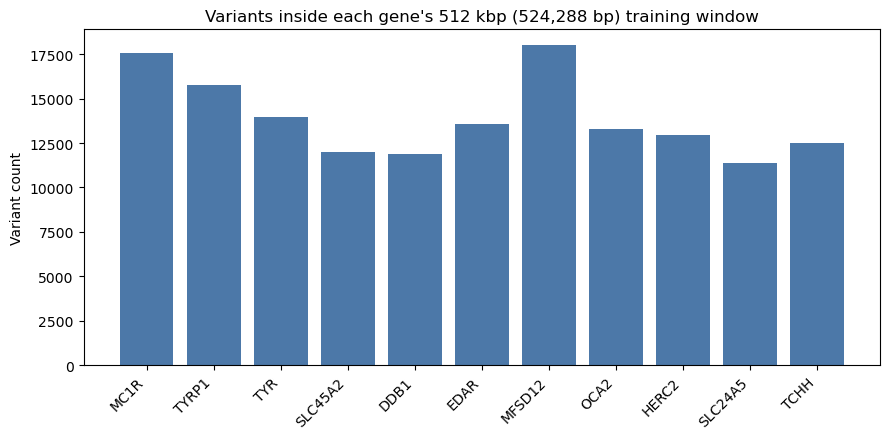

In [79]:
# Palette matching the dataviz skill's brand-neutral default (swap for a house palette if desired).
CATEGORY_COLORS = {
    "SNV": "#4C78A8",
    "Insertion": "#F58518",
    "Deletion": "#E45756",
    "Other": "#B0B0B0",
}

counts_per_gene = variants_df.groupby("gene").size().reindex(GENES)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(counts_per_gene.index, counts_per_gene.values, color="#4C78A8")
ax.set_ylabel("Variant count")
ax.set_title("Variants inside each gene's 512 kbp (524,288 bp) training window")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
plt.show()

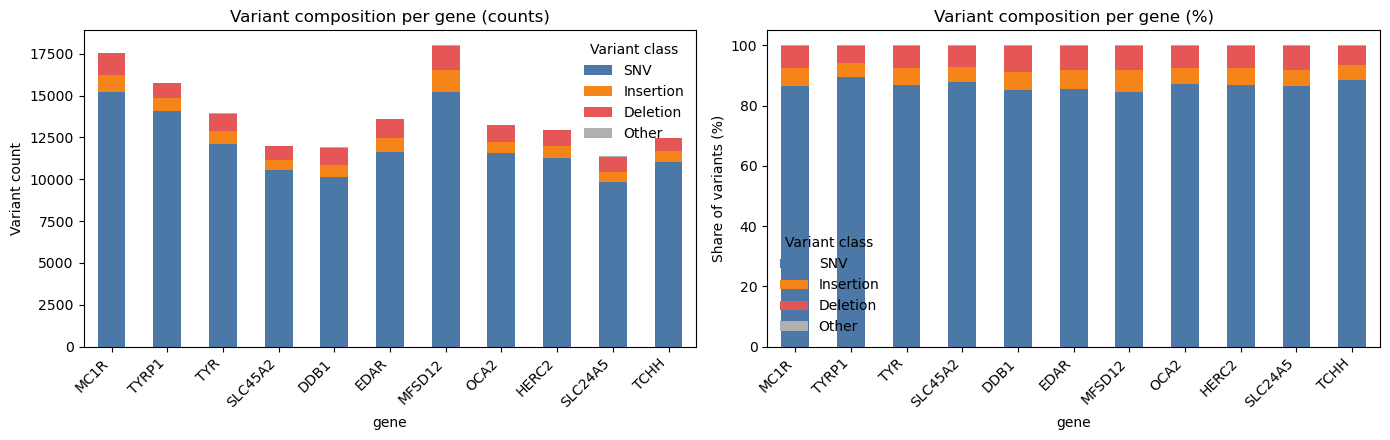

Overall composition across all 11 genes:
variant_class
SNV          132644
Deletion      11290
Insertion      8633
Other           251
Name: count, dtype: int64
variant_class
SNV          86.8%
Deletion     7.39%
Insertion    5.65%
Other        0.16%
Name: count, dtype: object


In [80]:
composition = (
    variants_df.groupby(["gene", "variant_class"]).size().unstack(fill_value=0)
    .reindex(columns=["SNV", "Insertion", "Deletion", "Other"], fill_value=0)
    .reindex(GENES)
)
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
composition.plot(kind="bar", stacked=True, ax=axes[0], color=[CATEGORY_COLORS[c] for c in composition.columns])
axes[0].set_title("Variant composition per gene (counts)")
axes[0].set_ylabel("Variant count")
axes[0].tick_params(axis="x", rotation=45)

composition_pct.plot(kind="bar", stacked=True, ax=axes[1], color=[CATEGORY_COLORS[c] for c in composition_pct.columns])
axes[1].set_title("Variant composition per gene (%)")
axes[1].set_ylabel("Share of variants (%)")
axes[1].tick_params(axis="x", rotation=45)
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.legend(title="Variant class", frameon=False)
fig.tight_layout()
plt.show()

overall = variants_df["variant_class"].value_counts()
print("Overall composition across all 11 genes:")
print(overall)
print((overall / overall.sum() * 100).round(2).astype(str) + "%")

## Section 3 -- Survey all AlphaGenome output tracks

`OutputType` enumerates every family of track AlphaGenome can predict. We first list every
track available for *any* of them (not just `rna_seq`), then pick a subset to actually fetch for
the relevance heuristic in Section 5.

In [81]:
OUTPUT_METADATA_ATTRS = [
    "rna_seq", "cage", "dnase", "atac", "chip_histone", "chip_tf",
    "splice_sites", "splice_junctions", "splice_site_usage", "procap", "contact_maps",
]

output_metadata = client.output_metadata(organism=ORGANISM)

track_frames = []
for attr in OUTPUT_METADATA_ATTRS:
    df = getattr(output_metadata, attr, None)
    if df is None or len(df) == 0:
        continue
    df = df.copy()
    df["output_type"] = attr.upper()
    track_frames.append(df)

all_tracks_df = pd.concat(track_frames, ignore_index=True)
print(f"Total tracks available across all OutputTypes: {len(all_tracks_df)}")
all_tracks_df.groupby("output_type").size().sort_values(ascending=False)

Total tracks available across all OutputTypes: 5563


output_type
CHIP_TF              1617
CHIP_HISTONE         1116
SPLICE_SITE_USAGE     734
RNA_SEQ               667
CAGE                  546
SPLICE_JUNCTIONS      367
DNASE                 305
ATAC                  167
CONTACT_MAPS           28
PROCAP                 12
SPLICE_SITES            4
dtype: int64

In [82]:
pigmentation_tracks_df = all_tracks_df[all_tracks_df.get("ontology_curie").isin(ONTOLOGY_TERMS)] \
    if "ontology_curie" in all_tracks_df.columns else all_tracks_df.iloc[0:0]
print(f"Tracks matching the pigmentation config's 3 ontology terms {ONTOLOGY_TERMS}: {len(pigmentation_tracks_df)}")
pigmentation_tracks_df.groupby("output_type").size()

Tracks matching the pigmentation config's 3 ontology terms ['CL:1000458', 'CL:0000346', 'CL:2000092']: 15


output_type
RNA_SEQ              6
SPLICE_JUNCTIONS     3
SPLICE_SITE_USAGE    6
dtype: int64

**Track selection rationale.**

The CNN's input shape is architecturally fixed by the trained config
(`alphagenome_outputs: ["rna_seq"]`, 3 ontology terms x 2 strands = 6 rows/haplotype/gene feeding
`CNN2AncestryPredictor`'s `Conv2d` stage-1 kernel of height 6). Adding more track types there
would break that fixed geometry -- so the extra tracks below are used **only** for the Section 5
heuristic, to help *rank* which variants are worth the expensive `predict_variant` + CNN
treatment, not as CNN input.

Chosen for the heuristic:

- **ATAC + DNASE** -- chromatin accessibility; the standard proxy for "is this position inside an
  active regulatory element" (promoter, enhancer, open chromatin).
- **CAGE** -- marks active transcription start sites, i.e. promoters/enhancers with initiation
  activity.
- **CHIP_HISTONE** (and **CHIP_TF** where available) -- active enhancer/promoter histone marks
  and transcription-factor occupancy; direct evidence of a regulatory element.
- **SPLICE_SITES** / **SPLICE_SITE_USAGE** -- catches variants near splice boundaries even when
  they sit outside any ATAC/CAGE peak (a common way small indels disrupt expression).
- **RNA_SEQ** is also fetched here (reused later as the Section 7 "pure reference" baseline) --
  it is both a direct expression signal and the CNN's actual training input.

Deliberately **excluded** from the heuristic to keep it fast and interpretable:

- **CONTACT_MAPS** -- 3D chromatin contacts are not naturally reducible to a per-base relevance
  score for this use case.
- **PROCAP** / **SPLICE_JUNCTIONS** -- informative, but largely redundant here with
  CAGE/splice-site tracks already fetched; skipped as a deliberate scope-narrowing choice, not an
  oversight.

In [83]:
HEURISTIC_OUTPUT_TYPES = [
    dna_client.OutputType.RNA_SEQ,
    dna_client.OutputType.ATAC,
    dna_client.OutputType.DNASE,
    dna_client.OutputType.CAGE,
    dna_client.OutputType.CHIP_HISTONE,
    dna_client.OutputType.CHIP_TF,
    dna_client.OutputType.SPLICE_SITES,
]
CNN_OUTPUT_TYPES = [dna_client.OutputType.RNA_SEQ]
print([o.name for o in HEURISTIC_OUTPUT_TYPES])

['RNA_SEQ', 'ATAC', 'DNASE', 'CAGE', 'CHIP_HISTONE', 'CHIP_TF', 'SPLICE_SITES']


## Section 4 -- Reference-window AlphaGenome predictions per gene

One `predict_interval` call per gene on the **unmodified reference** sequence, over the full
524,288 bp window and the broader track set chosen above, filtered to the 3 pigmentation
ontology terms where available. Results are cached to disk (these calls are the expensive
backbone reused by every variant's heuristic score in Section 5, and by the Section 7 baseline
tensor).

In [84]:
import dataclasses

REF_PRED_CACHE_DIR = REPO_ROOT / "notebooks" / ".cache" / "alphagenome_reference_predictions"
REF_PRED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ATAC/DNASE/CAGE/CHIP_HISTONE/CHIP_TF/SPLICE_SITES have no tracks profiled for the pigmentation
# config's 3 rare primary cell types (confirmed empirically below: only 15 tracks total exist for
# these ontology CURIEs, all RNA_SEQ/SPLICE_JUNCTIONS/SPLICE_SITE_USAGE). An ontology-filtered
# predict_interval silently returns 0-track arrays for them rather than raising, so they are
# fetched unfiltered (every profiled biosample) instead. RNA_SEQ still uses the exact 3
# melanocyte/hair-follicle ontology terms, since it must match the CNN's own input.
BROAD_HEURISTIC_OUTPUTS = [
    dna_client.OutputType.ATAC,
    dna_client.OutputType.DNASE,
    dna_client.OutputType.CAGE,
    dna_client.OutputType.CHIP_HISTONE,
    dna_client.OutputType.CHIP_TF,
    dna_client.OutputType.SPLICE_SITES,
]


def predict_reference_interval(gene: str, row: pd.Series):
    cache_path = REF_PRED_CACHE_DIR / f"{gene}.v2.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    interval = genome.Interval(chromosome=row["chrom"], start=int(row["start"]), end=int(row["end"]))
    cell_type_output = client.predict_interval(
        interval,
        organism=ORGANISM,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=ONTOLOGY_TERMS,
    )
    broad_output = client.predict_interval(
        interval,
        organism=ORGANISM,
        requested_outputs=BROAD_HEURISTIC_OUTPUTS,
        ontology_terms=None,
    )
    output = dataclasses.replace(
        cell_type_output,
        atac=broad_output.atac,
        dnase=broad_output.dnase,
        cage=broad_output.cage,
        chip_histone=broad_output.chip_histone,
        chip_tf=broad_output.chip_tf,
        splice_sites=broad_output.splice_sites,
    )
    with open(cache_path, "wb") as f:
        pickle.dump(output, f)
    return output


reference_outputs = {}
for gene, row in windows_df.set_index("gene").iterrows():
    print(f"Fetching reference prediction for {gene}...")
    reference_outputs[gene] = predict_reference_interval(gene, row)
print("Done.")

Fetching reference prediction for DDB1...
Fetching reference prediction for EDAR...
Fetching reference prediction for HERC2...
Fetching reference prediction for MC1R...
Fetching reference prediction for MFSD12...
Fetching reference prediction for OCA2...
Fetching reference prediction for SLC24A5...
Fetching reference prediction for SLC45A2...
Fetching reference prediction for TCHH...
Fetching reference prediction for TYR...
Fetching reference prediction for TYRP1...
Done.


In [85]:
example = reference_outputs[GENES[0]]
for attr in ["rna_seq", "atac", "dnase", "cage", "chip_histone", "chip_tf", "splice_sites"]:
    track_data = getattr(example, attr, None)
    if track_data is None:
        print(f"{attr:>14}: not returned")
        continue
    print(f"{attr:>14}: values.shape={track_data.values.shape}, tracks={list(track_data.metadata.get('name', []))[:3]}...")

       rna_seq: values.shape=(524288, 6), tracks=['CL:0000346 total RNA-seq', 'CL:1000458 total RNA-seq', 'CL:2000092 total RNA-seq']...
          atac: values.shape=(524288, 167), tracks=['CL:0000084 ATAC-seq', 'CL:0000100 ATAC-seq', 'CL:0000236 ATAC-seq']...
         dnase: values.shape=(524288, 305), tracks=['CL:0000047 DNase-seq', 'CL:0000084 DNase-seq', 'CL:0000115 DNase-seq']...
          cage: values.shape=(524288, 546), tracks=['LQhCAGE CL:0000077', 'LQhCAGE CL:0000136', 'LQhCAGE CL:0000767']...
  chip_histone: values.shape=(4096, 1116), tracks=['CL:0000047 Histone ChIP-seq H2AFZ', 'CL:0000047 Histone ChIP-seq H2AK5ac', 'CL:0000047 Histone ChIP-seq H2BK5ac']...
       chip_tf: values.shape=(4096, 1617), tracks=['CL:0000062 TF ChIP-seq CTCF', 'CL:0000115 TF ChIP-seq CTCF', 'CL:0000127 TF ChIP-seq CTCF']...
  splice_sites: values.shape=(524288, 4), tracks=['donor', 'acceptor', 'donor']...


**Empirical finding (fixed above).** The sanity check above originally showed `atac`, `dnase`,
`cage`, `chip_histone`, and `chip_tf` all coming back with **0 tracks** when filtered to the
pigmentation config's 3 ontology terms -- consistent with Section 3's track catalog, which shows
only 15 total tracks exist for these 3 CURIEs (all `RNA_SEQ` / `SPLICE_JUNCTIONS` /
`SPLICE_SITE_USAGE`). AlphaGenome's ENCODE-derived catalog simply has no ATAC-seq, DNase, CAGE, or
ChIP data profiled for melanocyte of skin / hair follicle dermal papilla cell / hair follicular
keratinocyte specifically.

`predict_reference_interval` now fetches `RNA_SEQ` ontology-filtered (must match the CNN's
melanocyte/hair-follicle input exactly) and the other five heuristic tracks **unfiltered** --
across every biosample AlphaGenome has profiled for that assay -- as a broader "is this
generally a regulatory-active position in any known cell type" proxy. This is a real limitation
of the heuristic (it can no longer claim cell-type specificity for accessibility/CAGE/ChIP), but
it's the only way to get non-empty signal for those assay types here, and it's still a reasonable
prior for "does this position look regulatory at all." `track_value_at_position` (Section 5) was
also fixed to divide by `track_data.resolution` -- ChIP tracks are binned at 128 bp, not 1
bp/row, so the previous version would have silently misindexed them once they had real data.

Re-run the cell above (delete `notebooks/.cache/alphagenome_reference_predictions/` first, or
rely on the new `*.v2.pkl` cache filenames to bypass the stale broken cache automatically) before
continuing to Section 5.

## Section 5 -- Heuristic relevance score

For every variant with a simple `ACGTN` REF/ALT (required later by `predict_variant`; symbolic
or complex "Other" variants stay in the Section 2 census but are not eligible for top-k), combine
several signals -- already fetched in Section 4, read at the variant's position -- into one
documented, weighted heuristic. This is explicitly a heuristic, not a learned score.

In [86]:
def track_value_at_position(track_data, window_start: int, pos_1based: int) -> float:
    # Mean across all returned tracks of a TrackData at a given genomic position, accounting for
    # the track's own resolution (e.g. ChIP tracks are binned at 128 bp, not 1 bp/row) and for
    # tracks with zero columns (see the Section 4 empirical-finding note above).
    if track_data is None or track_data.values.shape[-1] == 0:
        return 0.0
    idx = ((pos_1based - 1) - window_start) // track_data.resolution
    values = track_data.values
    if idx < 0 or idx >= values.shape[0]:
        return 0.0
    row = values[idx]
    return float(np.mean(row)) if np.ndim(row) > 0 else float(row)


# Intended multi-signal weighting (rationale per component below). `pop_differentiation`'s
# weight is deliberately kept at 0 in the score actually used to rank/select candidates:
# its value is an allele-frequency gap between the *same two population groups* used as the
# CNN's classification label, i.e. it is itself a GWAS-style association signal. Folding it
# into the score that picks TWAS candidates would let GWAS-flavored evidence leak into a
# selection that's supposed to be driven only by AlphaGenome-derived features, contaminating
# the TWAS-vs-GWAS comparison later in the notebook (Section 9). The remaining components are
# renormalized to sum to 1.0 so `heuristic_score` stays on a comparable [0, 1]-ish scale.
# (Earlier revision of this cell accidentally zeroed every weight but "accessibility" --
# collapsing the heuristic to a single signal despite the multi-signal design described above.
# Restored here.)
_INTENDED_WEIGHTS = {
    "accessibility": 0.30,   # ATAC + DNASE: open chromatin => likely regulatory (broad, not melanocyte-specific -- see Section 4 note)
    "promoter_cage": 0.20,   # CAGE: active TSS/promoter/enhancer signal (broad, not melanocyte-specific)
    "chromatin_state": 0.15, # CHIP_HISTONE + CHIP_TF: active enhancer/promoter marks, TF occupancy (broad)
    "splice_proximity": 0.15,# SPLICE_SITES: splicing disruption potential
    "variant_type": 0.05,    # small fixed bump for INS/DEL vs SNV (larger local disruption)
    "pop_differentiation": 0.15,  # allele-frequency gap between the model's own strong/weak pigmentation groups -- see note above
}
_ACTIVE_COMPONENTS = [c for c in _INTENDED_WEIGHTS if c != "pop_differentiation"]
_ACTIVE_TOTAL = sum(_INTENDED_WEIGHTS[c] for c in _ACTIVE_COMPONENTS)
HEURISTIC_WEIGHTS = {c: _INTENDED_WEIGHTS[c] / _ACTIVE_TOTAL for c in _ACTIVE_COMPONENTS}
HEURISTIC_WEIGHTS["pop_differentiation"] = 0.0
assert abs(sum(HEURISTIC_WEIGHTS.values()) - 1.0) < 1e-9

STRONG_POPS = set(config.output.derived_targets["pigmentation"].class_map["strong pigmentation"])
WEAK_POPS = set(config.output.derived_targets["pigmentation"].class_map["weak pigmentation"])
print("Strong pigmentation populations:", STRONG_POPS)
print("Weak pigmentation populations  :", WEAK_POPS)

Strong pigmentation populations: {'ESN', 'GWD', 'LWK', 'MSL', 'YRI'}
Weak pigmentation populations  : {'FIN', 'GBR', 'CEU'}


In [87]:
def population_for_sample(pedigree: dict, sample_id: str):
    return pedigree.get(sample_id, {}).get("population")


with open(DATASET_DIR / "dataset_metadata.json") as f:
    dataset_metadata = json.load(f)
pedigree = dataset_metadata.get("individuals_pedigree", {})


def build_population_af_lookup(gene: str, gene_window: pd.Series) -> dict:
    # One `bcftools query` per gene window -- not per variant (that was the notebook's original
    # approach and took ~152k subprocess spawns to run; see Section 2's fetch_window_variants for
    # the same per-gene batching pattern). Returns {(pos, ref, alt): |AF(strong) - AF(weak)|} for
    # every allele in the window, built from one pass over the region's genotypes.
    region = f"{gene_window['chrom']}:{gene_window['start'] + 1}-{gene_window['end']}"
    cmd = ["bcftools", "query", "-r", region, "-f", "%POS\t%REF\t%ALT[\t%SAMPLE=%GT]\n", gene_window["vcf_path"]]
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)

    lookup = {}
    for line in result.stdout.splitlines():
        fields = line.split("\t")
        pos, ref, alt_field = int(fields[0]), fields[1], fields[2]
        alts = alt_field.split(",")

        strong_total = weak_total = 0
        strong_alt_counts = [0] * len(alts)
        weak_alt_counts = [0] * len(alts)
        for sample_gt in fields[3:]:
            if "=" not in sample_gt:
                continue
            sample_id, gt = sample_gt.split("=", 1)
            pop = population_for_sample(pedigree, sample_id)
            if pop not in STRONG_POPS and pop not in WEAK_POPS:
                continue
            alleles = [a for a in gt.replace("|", "/").split("/") if a not in (".", "")]
            if not alleles:
                continue
            counts = strong_alt_counts if pop in STRONG_POPS else weak_alt_counts
            for a in alleles:
                alt_idx = int(a)
                if 1 <= alt_idx <= len(alts):
                    counts[alt_idx - 1] += 1
            if pop in STRONG_POPS:
                strong_total += len(alleles)
            else:
                weak_total += len(alleles)

        for alt_idx, alt in enumerate(alts):
            strong_af = strong_alt_counts[alt_idx] / strong_total if strong_total else 0.0
            weak_af = weak_alt_counts[alt_idx] / weak_total if weak_total else 0.0
            lookup[(pos, ref, alt)] = abs(strong_af - weak_af)
    return lookup

In [88]:
VARIANT_TYPE_BUMP = {"SNV": 0.0, "Insertion": 1.0, "Deletion": 1.0, "Other": 0.0}

eligible = variants_df[variants_df["variant_class"].isin(["SNV", "Insertion", "Deletion"])].copy()
print(f"Eligible variants (simple ACGTN REF/ALT) for heuristic scoring: {len(eligible)} / {len(variants_df)}")

rows = []
for gene, group in eligible.groupby("gene"):
    ref_output = reference_outputs[gene]
    gene_window = windows_df.set_index("gene").loc[gene]
    window_start = int(gene_window["start"])
    af_lookup = build_population_af_lookup(gene, gene_window)  # 1 bcftools call for the whole gene window
    for _, v in group.iterrows():
        atac_v = track_value_at_position(ref_output.atac, window_start, v["pos"])
        dnase_v = track_value_at_position(ref_output.dnase, window_start, v["pos"])
        cage_v = track_value_at_position(ref_output.cage, window_start, v["pos"])
        histone_v = track_value_at_position(ref_output.chip_histone, window_start, v["pos"])
        tf_v = track_value_at_position(ref_output.chip_tf, window_start, v["pos"])
        splice_v = track_value_at_position(ref_output.splice_sites, window_start, v["pos"])
        rows.append({
            **v.to_dict(),
            "accessibility_raw": (atac_v + dnase_v) / 2.0,
            "promoter_cage_raw": cage_v,
            "chromatin_state_raw": (histone_v + tf_v) / 2.0,
            "splice_proximity_raw": splice_v,
            "variant_type_raw": VARIANT_TYPE_BUMP[v["variant_class"]],
            "pop_differentiation_raw": af_lookup.get((v["pos"], v["ref"], v["alt"]), 0.0),
        })

scored_df = pd.DataFrame(rows)
print(f"Computed population-differentiation component for {len(scored_df)} variants ({len(GENES)} bcftools calls total).")
scored_df.head()

Eligible variants (simple ACGTN REF/ALT) for heuristic scoring: 152567 / 152818
Computed population-differentiation component for 152567 variants (11 bcftools calls total).


,gene,chrom,pos,id,ref,alt,variant_class,accessibility_raw,promoter_cage_raw,chromatin_state_raw,splice_proximity_raw,variant_type_raw,pop_differentiation_raw
0,DDB1,chr11,61058959,11:61058959:C:T,C,T,SNV,0.040644,0.003962,98.372425,1.698267e-06,0.0,0.000000
1,DDB1,chr11,61058960,11:61058960:G:A,G,A,SNV,0.004445,0.004274,98.372425,3.272435e-06,0.0,0.057610
2,DDB1,chr11,61058988,11:61058988:TCTC:T,TCTC,T,Deletion,0.007847,0.002052,98.372425,6.452901e-06,1.0,0.016898
3,DDB1,chr11,61058998,11:61058998:C:T,C,T,SNV,0.033477,0.002120,98.372425,9.997748e-07,0.0,0.000000
4,DDB1,chr11,61059073,11:61059073:G:A,G,A,SNV,0.003452,0.001768,106.905415,4.443573e-07,0.0,0.001422


In [89]:
RAW_COLS = {
    "accessibility": "accessibility_raw",
    "promoter_cage": "promoter_cage_raw",
    "chromatin_state": "chromatin_state_raw",
    "splice_proximity": "splice_proximity_raw",
    "variant_type": "variant_type_raw",
    "pop_differentiation": "pop_differentiation_raw",
}


def minmax_per_gene(df: pd.DataFrame, raw_col: str) -> pd.Series:
    def _norm(group):
        lo, hi = group.min(), group.max()
        if hi - lo < 1e-12:
            return pd.Series(0.0, index=group.index)
        return (group - lo) / (hi - lo)
    return df.groupby("gene")[raw_col].transform(_norm)


for component, raw_col in RAW_COLS.items():
    scored_df[f"{component}_norm"] = minmax_per_gene(scored_df, raw_col)

scored_df["heuristic_score"] = sum(
    HEURISTIC_WEIGHTS[c] * scored_df[f"{c}_norm"] for c in HEURISTIC_WEIGHTS
)
scored_df = scored_df.sort_values("heuristic_score", ascending=False).reset_index(drop=True)
scored_df[["gene", "chrom", "pos", "ref", "alt", "variant_class", "heuristic_score"]].head(15)

,gene,chrom,pos,ref,alt,variant_class,heuristic_score
0,DDB1,chr11,61362181,G,T,SNV,0.520533
1,SLC45A2,chr5,34008084,A,G,SNV,0.516509
2,TCHH,chr1,151909855,T,C,SNV,0.505793
3,SLC24A5,chr15,48330984,A,T,SNV,0.469087
4,OCA2,chr15,28096201,G,A,SNV,0.461869
5,HERC2,chr15,28096201,G,A,SNV,0.461247
6,EDAR,chr2,108719495,G,C,SNV,0.452983
7,EDAR,chr2,108786669,T,C,SNV,0.444760
8,MC1R,chr16,89873521,T,C,SNV,0.435435
9,TCHH,chr1,152036993,G,C,SNV,0.432598


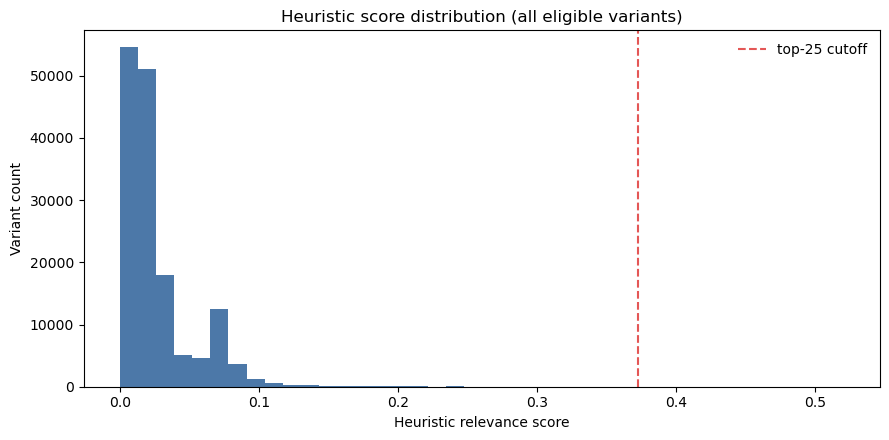

,gene,chrom,pos,ref,alt,variant_class,heuristic_score
0,DDB1,chr11,61362181,G,T,SNV,0.520533
1,SLC45A2,chr5,34008084,A,G,SNV,0.516509
2,TCHH,chr1,151909855,T,C,SNV,0.505793
3,SLC24A5,chr15,48330984,A,T,SNV,0.469087
4,OCA2,chr15,28096201,G,A,SNV,0.461869
5,HERC2,chr15,28096201,G,A,SNV,0.461247
6,EDAR,chr2,108719495,G,C,SNV,0.452983
7,EDAR,chr2,108786669,T,C,SNV,0.444760
8,MC1R,chr16,89873521,T,C,SNV,0.435435
9,TCHH,chr1,152036993,G,C,SNV,0.432598


In [90]:
TOP_K = 25
top_k_df = scored_df.head(TOP_K).copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(scored_df["heuristic_score"], bins=40, color="#4C78A8")
ax.axvline(top_k_df["heuristic_score"].min(), color="#E45756", linestyle="--", label=f"top-{TOP_K} cutoff")
ax.set_xlabel("Heuristic relevance score")
ax.set_ylabel("Variant count")
ax.set_title("Heuristic score distribution (all eligible variants)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

top_k_df[["gene", "chrom", "pos", "ref", "alt", "variant_class", "heuristic_score"]]

## Section 5b -- Curated benchmark variant set (published POS/NEG controls)

`snps.csv` (repo root) is a hand-curated set of pigmentation variants from primary literature,
each labeled `control_class` (`POS` = published regulatory/expression variant, should show a
real effect; `NEG` = coding/protein-level variant, expected to look ~null since the CNN only
ever sees `rna_seq`; `SUPP` = supporting/region-level) and `expected_rnaseq_signal` (`VISIBLE`
vs `NULL_CODING`). This gives Sections 6-8 an actual labeled ground truth instead of only an
unlabeled heuristic top-k.

Only rsIDs are in the CSV, not GRCh38 coordinates, so coordinates below were resolved via the
`dbsnp_database` skill (NCBI dbSNP Variation Services, assembly `GCF_000001405.40`) -- see
`.licenses/dbsnp_database_LICENSE.txt` for the NCBI usage-terms notice recorded when that skill
ran. Three genes referenced in the CSV (`KITLG`, `ASIP`, `BNC2`) and one region-level placeholder
row (`DDB1_REGION`, no rsID) fall outside this notebook's 11 trained gene windows and are dropped
below with a printed reason -- they cannot be scored by this pipeline. The remaining 30 rsIDs all
resolve to positions inside their assigned window, including several inside the `OCA2`/`HERC2`
window overlap (disambiguated using the CSV's own `gene` column, since a variant in the overlap
region shows up as two separate rows in `scored_df` -- one per overlapping gene window -- with
independently-computed heuristic components).

Every matched benchmark variant is unioned into `top_k_df` below (in addition to the heuristic
top-`TOP_K`), so Sections 6-8 run the real `predict_variant` + CNN stage on every curated POS/NEG
control, not just whatever the cheap heuristic ranks highly -- the negative coding controls in
particular are *expected* to rank low on the heuristic (that's the point: confirming they also
come back ~null from the actual CNN, not just from the cheap proxy).

**Known limitation, not fixed here (kept as-is deliberately):** in Section 7/8,
`build_full_tensor` only injects a variant into the gene block matching its `scored_df`-assigned
`gene` tag (see `build_gene_block(gene, variant_row if variant_row["gene"] == gene else None)`).
For a variant physically inside the OCA2/HERC2 overlap, that means an "OCA2-tagged" row perturbs
only the OCA2 block and leaves the HERC2 block at pure reference, even though the same genomic
position also falls inside HERC2's own window -- i.e. the synthetic individual's HERC2 sequence
silently omits a variant that a real individual carrying it would have. This is a real inconsistency
in the single-variant synthetic-individual test, not a bug in the windowing itself (the overlap is
biologically real -- `rs12913832` is a canonical HERC2-intron enhancer that regulates OCA2 -- so the
windows are not being trimmed to remove it). Left undocumented until now; flagging so it's not
mistaken for a non-issue when interpreting cross-gene comparisons for overlap-region variants.

In [91]:
BENCHMARK_CSV_PATH = REPO_ROOT / "snps.csv"
benchmark_raw_df = pd.read_csv(BENCHMARK_CSV_PATH, comment="#")

# GRCh38 coordinates resolved via the `dbsnp_database` skill (NCBI Variation Services, assembly
# GCF_000001405.40) on 2026-07-11, since snps.csv only carries rsIDs. `dbsnp_alts` lists every
# alternate allele dbSNP has observed at that position (a position can be multiallelic); the
# matching cell below picks whichever single ALT actually appears in this window's 1000-Genomes
# high-coverage VCF.
DBSNP_GRCH38_COORDS = {
    "rs1426654":   ("chr15", 48134287, "A", ["C", "G", "T"]),
    "rs16891982":  ("chr5",  33951588, "C", ["A", "G"]),
    "rs28777":     ("chr5",  33958854, "C", ["A", "G"]),
    "rs26722":     ("chr5",  33963765, "C", ["T"]),
    "rs1042602":   ("chr11", 89178528, "C", ["A"]),
    "rs1126809":   ("chr11", 89284793, "G", ["A"]),
    "rs1393350":   ("chr11", 89277878, "G", ["A"]),
    "rs12913832":  ("chr15", 28120472, "A", ["C", "G"]),
    "rs1129038":   ("chr15", 28111713, "C", ["A", "G", "T"]),
    "rs4932620":   ("chr15", 28269135, "T", ["A", "C", "G"]),
    "rs6497271":   ("chr15", 28120285, "A", ["C", "G", "T"]),
    "rs1800407":   ("chr15", 27985172, "C", ["T"]),
    "rs1800414":   ("chr15", 27951891, "T", ["A", "C", "G"]),
    "rs74653330":  ("chr15", 27983407, "C", ["A", "G", "T"]),
    "rs1800404":   ("chr15", 27990627, "C", ["A", "T"]),
    "rs7495174":   ("chr15", 28099092, "A", ["G", "T"]),
    "rs1805007":   ("chr16", 89919709, "C", ["A", "G", "T"]),
    "rs1805008":   ("chr16", 89919736, "C", ["A", "T"]),
    "rs1805009":   ("chr16", 89920138, "G", ["A", "C", "T"]),
    "rs1805006":   ("chr16", 89919510, "C", ["A", "G"]),
    "rs11547464":  ("chr16", 89919683, "G", ["A"]),
    "rs1110400":   ("chr16", 89919722, "T", ["C"]),
    "rs1805005":   ("chr16", 89919436, "G", ["T"]),
    "rs2228479":   ("chr16", 89919532, "G", ["A", "C"]),
    "rs885479":    ("chr16", 89919746, "G", ["A", "C", "T"]),
    "rs683":       ("chr9",  12709305, "C", ["A", "T"]),
    "rs1408799":   ("chr9",  12672097, "T", ["C"]),
    "rs10424065":  ("chr19", 3545024,  "C", ["A", "G", "T"]),
    "rs6510760":   ("chr19", 3565255,  "G", ["A", "C"]),
    "rs112332856": ("chr19", 3565601,  "T", ["C"]),
    "rs56203814":  ("chr19", 3544894,  "C", ["A", "G", "T"]),
}

OUT_OF_SCOPE_GENES = {"KITLG", "ASIP", "BNC2"}

in_scope_mask = ~benchmark_raw_df["gene"].isin(OUT_OF_SCOPE_GENES) & benchmark_raw_df["rsid"].isin(DBSNP_GRCH38_COORDS)
dropped = benchmark_raw_df[~in_scope_mask]
print(f"Dropping {len(dropped)}/{len(benchmark_raw_df)} benchmark rows outside the 11 trained gene windows "
      f"or without a resolved rsID (e.g. the region-level DDB1_REGION placeholder):")
for _, r in dropped.iterrows():
    reason = "gene outside the 11 trained windows" if r["gene"] in OUT_OF_SCOPE_GENES else "no rsID / not resolved"
    print(f"  {str(r['rsid']):>14} ({str(r['gene']):>12}): {reason}")

benchmark_df = benchmark_raw_df[in_scope_mask].copy()
coords = benchmark_df["rsid"].map(DBSNP_GRCH38_COORDS)
benchmark_df["chrom"] = coords.map(lambda c: c[0])
benchmark_df["pos"] = coords.map(lambda c: c[1])
benchmark_df["dbsnp_ref"] = coords.map(lambda c: c[2])
benchmark_df["dbsnp_alts"] = coords.map(lambda c: c[3])
benchmark_df[["rsid", "gene", "chrom", "pos", "dbsnp_ref", "dbsnp_alts", "control_class", "expected_rnaseq_signal"]]

Dropping 8/39 benchmark rows outside the 11 trained gene windows or without a resolved rsID (e.g. the region-level DDB1_REGION placeholder):
      rs12821256 (       KITLG): gene outside the 11 trained windows
        rs642742 (       KITLG): gene outside the 11 trained windows
       rs6058017 (        ASIP): gene outside the 11 trained windows
       rs2378249 (        ASIP): gene outside the 11 trained windows
       rs1015362 (        ASIP): gene outside the 11 trained windows
      rs10756819 (        BNC2): gene outside the 11 trained windows
      rs62543565 (        BNC2): gene outside the 11 trained windows
     DDB1_REGION (DDB1/TMEM138): no rsID / not resolved


,rsid,gene,chrom,pos,dbsnp_ref,dbsnp_alts,control_class,expected_rnaseq_signal
0,rs1426654,SLC24A5,chr15,48134287,A,"[C, G, T]",NEG,NULL_CODING
1,rs16891982,SLC45A2,chr5,33951588,C,"[A, G]",NEG,NULL_CODING
2,rs28777,SLC45A2,chr5,33958854,C,"[A, G]",SUPP,VISIBLE
3,rs26722,SLC45A2,chr5,33963765,C,[T],NEG,NULL_CODING
4,rs1042602,TYR,chr11,89178528,C,[A],NEG,NULL_CODING
5,rs1126809,TYR,chr11,89284793,G,[A],NEG,NULL_CODING
6,rs1393350,TYR,chr11,89277878,G,[A],POS,VISIBLE
7,rs12913832,HERC2,chr15,28120472,A,"[C, G]",POS,VISIBLE
8,rs1129038,HERC2,chr15,28111713,C,"[A, G, T]",POS,VISIBLE
9,rs4932620,HERC2,chr15,28269135,T,"[A, C, G]",POS,VISIBLE


In [92]:
def match_benchmark_variant(row):
    candidates = scored_df[
        (scored_df["gene"] == row["gene"])
        & (scored_df["chrom"] == row["chrom"])
        & (scored_df["pos"] == row["pos"])
        & (scored_df["ref"] == row["dbsnp_ref"])
        & (scored_df["alt"].isin(row["dbsnp_alts"]))
    ]
    return candidates.index[0] if len(candidates) else np.nan


benchmark_df["scored_df_index"] = benchmark_df.apply(match_benchmark_variant, axis=1)
n_matched = benchmark_df["scored_df_index"].notna().sum()
print(f"Matched {n_matched}/{len(benchmark_df)} benchmark variants against this window's actual "
      f"1000-Genomes high-coverage variant calls.")

unmatched = benchmark_df[benchmark_df["scored_df_index"].isna()]
if len(unmatched):
    print("Unmatched (not polymorphic in this cohort/window, or a non-ACGTN/complex allele -- "
          "excluded upstream by Section 5's eligibility filter, same as predict_variant would require):")
    for _, r in unmatched.iterrows():
        print(f"  {r['rsid']:>14} ({r['gene']:>8}) {r['chrom']}:{r['pos']}")

benchmark_matched_df = benchmark_df[benchmark_df["scored_df_index"].notna()].copy()
benchmark_matched_df["scored_df_index"] = benchmark_matched_df["scored_df_index"].astype(int)
benchmark_annotations = benchmark_matched_df.set_index("scored_df_index")[
    ["rsid", "control_class", "expected_rnaseq_signal", "consequence", "notes"]
]
benchmark_annotations

Matched 31/31 benchmark variants against this window's actual 1000-Genomes high-coverage variant calls.


,rsid,control_class,expected_rnaseq_signal,consequence,notes
scored_df_index,,,,,
94262,rs1426654,NEG,NULL_CODING,missense,Largest single EUR-vs-AFR effect; derived alle...
110635,rs16891982,NEG,NULL_CODING,missense,"Coding, BUT reported associated with SLC45A2 E..."
71709,rs28777,SUPP,VISIBLE,intron/near-gene,"HIrisPlex-S skin SNP; non-coding, candidate ex..."
76146,rs26722,NEG,NULL_CODING,missense,Coding; low relevance in EUR/AFR split (East-A...
37352,rs1042602,NEG,NULL_CODING,missense,Coding nonsyn; freckling/skin. Expected null i...
46219,rs1126809,NEG,NULL_CODING,missense,Thermosensitive coding variant; eye/skin. Expe...
37062,rs1393350,POS,VISIBLE,intron/near-gene,Non-coding TYR-region GWAS hit (freckles/pigme...
31243,rs12913832,POS,VISIBLE,intron(regulatory enhancer of OCA2),Canonical distal enhancer variant; modulates O...
22681,rs1129038,POS,VISIBLE,intron(regulatory),In strong LD with rs12913832; eye colour/melas...


In [93]:
scored_df = scored_df.join(benchmark_annotations)
scored_df["is_benchmark"] = scored_df["rsid"].notna()
scored_df["heuristic_percentile_global"] = scored_df["heuristic_score"].rank(ascending=False, pct=True)

heuristic_top_k_index = set(scored_df.sort_values("heuristic_score", ascending=False).head(TOP_K).index)
benchmark_index = set(benchmark_annotations.index)
top_k_df = scored_df.loc[sorted(heuristic_top_k_index | benchmark_index)].copy()

print(f"top_k_df: heuristic top-{TOP_K} ({len(heuristic_top_k_index)}) + benchmark ({len(benchmark_index)}) "
      f"-> {len(top_k_df)} unique variants going into Sections 6-8 "
      f"({len(benchmark_index - heuristic_top_k_index)} added solely because they're benchmark controls).")
top_k_df[top_k_df["is_benchmark"]][
    ["gene", "chrom", "pos", "ref", "alt", "rsid", "control_class", "expected_rnaseq_signal",
     "heuristic_score", "heuristic_percentile_global"]
].sort_values("heuristic_percentile_global")

top_k_df: heuristic top-25 (25) + benchmark (31) -> 56 unique variants going into Sections 6-8 (31 added solely because they're benchmark controls).


,gene,chrom,pos,ref,alt,rsid,control_class,expected_rnaseq_signal,heuristic_score,heuristic_percentile_global
411,OCA2,chr15,28099092,A,G,rs7495174,SUPP,VISIBLE,0.179246,0.002700
22681,HERC2,chr15,28111713,C,T,rs1129038,POS,VISIBLE,0.059505,0.148669
27708,HERC2,chr15,28120285,A,G,rs6497271,POS,VISIBLE,0.041196,0.181619
29776,MFSD12,chr19,3545024,C,T,rs10424065,POS,VISIBLE,0.037954,0.195173
30111,HERC2,chr15,28269135,T,C,rs4932620,POS,VISIBLE,0.037536,0.197369
30425,OCA2,chr15,27990627,C,T,rs1800404,POS,VISIBLE,0.037176,0.199427
31243,HERC2,chr15,28120472,A,G,rs12913832,POS,VISIBLE,0.036173,0.204789
32128,OCA2,chr15,27951891,T,C,rs1800414,NEG,NULL_CODING,0.035241,0.210589
34253,OCA2,chr15,27983407,C,T,rs74653330,NEG,NULL_CODING,0.033458,0.224518
34511,OCA2,chr15,27985172,C,T,rs1800407,NEG,NULL_CODING,0.033279,0.226209


## Section 6 -- AlphaGenome ALT-sequence prediction for the top-k variants

Per the AlphaGenome docs, `predict_variant(interval, variant, ...)` is the documented way to get
"the ALT sequence that is the reference genome modified by the variant": it substitutes
REF -> ALT internally and returns a `VariantOutput(reference, alternate)` with both outputs
already aligned to the same `interval`. This is used instead of manually splicing the FASTA and
calling `predict_sequence` twice (the approach `build_window_and_predict.py` uses when building
per-sample consensus haplotypes with `bcftools consensus`) -- redundant here since
`predict_variant` does it in one call. Only `RNA_SEQ` is requested since that is the CNN's sole
input signal.

In [94]:
VARIANT_PRED_CACHE_DIR = REPO_ROOT / "notebooks" / ".cache" / "alphagenome_variant_predictions"
VARIANT_PRED_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def predict_variant_effect(gene: str, window_row: pd.Series, variant_row: pd.Series):
    cache_key = f"{gene}_{variant_row['chrom']}_{variant_row['pos']}_{variant_row['ref']}_{variant_row['alt']}"
    cache_path = VARIANT_PRED_CACHE_DIR / f"{cache_key}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    interval = genome.Interval(
        chromosome=window_row["chrom"], start=int(window_row["start"]), end=int(window_row["end"])
    )
    variant = genome.Variant(
        chromosome=variant_row["chrom"],
        position=int(variant_row["pos"]),
        reference_bases=variant_row["ref"],
        alternate_bases=variant_row["alt"],
    )
    output = client.predict_variant(
        interval,
        variant,
        organism=ORGANISM,
        requested_outputs=CNN_OUTPUT_TYPES,
        ontology_terms=ONTOLOGY_TERMS,
    )
    with open(cache_path, "wb") as f:
        pickle.dump(output, f)
    return output


variant_outputs = {}
for i, v in top_k_df.iterrows():
    window_row = windows_df.set_index("gene").loc[v["gene"]]
    print(f"[{i + 1}/{len(top_k_df)}] predict_variant {v['gene']} {v['chrom']}:{v['pos']} {v['ref']}>{v['alt']}")
    key = (v["gene"], v["chrom"], v["pos"], v["ref"], v["alt"])
    variant_outputs[key] = predict_variant_effect(v["gene"], window_row, v)
print("Done.")

[1/56] predict_variant DDB1 chr11:61362181 G>T
[2/56] predict_variant SLC45A2 chr5:34008084 A>G
[3/56] predict_variant TCHH chr1:151909855 T>C
[4/56] predict_variant SLC24A5 chr15:48330984 A>T
[5/56] predict_variant OCA2 chr15:28096201 G>A
[6/56] predict_variant HERC2 chr15:28096201 G>A
[7/56] predict_variant EDAR chr2:108719495 G>C
[8/56] predict_variant EDAR chr2:108786669 T>C
[9/56] predict_variant MC1R chr16:89873521 T>C
[10/56] predict_variant TCHH chr1:152036993 G>C
[11/56] predict_variant TYR chr11:89491357 C>G
[12/56] predict_variant TCHH chr1:151993835 T>G
[13/56] predict_variant TCHH chr1:151909648 T>A
[14/56] predict_variant TYRP1 chr9:12814637 T>G
[15/56] predict_variant TCHH chr1:151909603 T>C
[16/56] predict_variant MFSD12 chr19:3627091 T>C
[17/56] predict_variant SLC24A5 chr15:48178319 C>T
[18/56] predict_variant TYR chr11:89491582 T>C
[19/56] predict_variant TCHH chr1:152052713 A>G
[20/56] predict_variant TYR chr11:89433497 T>G
[21/56] predict_variant DDB1 chr11:6142994

## Section 7 -- Align onto the `bcftools_chain` expanded axis & build CNN input

The CNN was trained on tensors built by `ProcessedGenomicDataset._process_window_haplotype_channels`,
which maps each haplotype's AlphaGenome `rna_seq` array onto a per-gene "expanded axis" (shared
across the whole cohort, built from real indels via `DynamicIndelAligner`), then crops to the
central `window_center_size` (32,768 bp). We reuse that machinery directly rather than
reimplementing it:

- `DynamicIndelAligner.get_alignment_axis(gene)` -- `expanded_index_map` (ref position ->
  expanded position) and `insertion_slots_by_ref`, built from real cohort indels.
- `DynamicIndelAligner.get_reference_centered_expanded_slice(gene, window_center_size)` -- the
  exact center crop used at training time.
- `indel_tensor_builder.build_aligned_haplotype_tensor` -- scatters a 1D per-base signal array
  onto the expanded axis given an "entry" (`copy_from_indices` / `expanded_indices` /
  `insertion_indices` / `deletion_indices`).

**Baseline** ("pure reference" individual): every gene's block uses the Section 4 reference
`rna_seq` array, placed via an *identity* entry (ref position `i` copies straight from array
index `i`, no insertions/deletions) -- exactly the pattern
`ProcessedGenomicDataset._aligned_reference_signal_row` uses for its own `delta_reference`
feature.

**Perturbed** (one variant injected): identical baseline, except the tested gene/haplotype's
block is built from the Section 6 `VariantOutput.alternate.rna_seq` array. For a pure SNV the
array is already coordinate-aligned with the reference (same length/frame), so the identity
entry works unchanged. For a small INS/DEL we build the entry analytically -- shifting
`copy_from_indices` by `len(alt) - len(ref)` downstream of the variant and (for insertions)
consuming the pre-reserved `insertion_slots_by_ref` slot -- mirroring exactly what
`bcftools_chain_mapper.build_chain_entry` does when parsing a real `bcftools consensus -c chain`
file, just computed directly from one variant's REF/ALT instead of a chain file.

This whole section depends on the training run having produced a checkpoint; it is guarded and
will simply report status if the checkpoint isn't ready yet.

In [95]:
EXPERIMENT_DIR = get_experiment_runs_dir(config) / generate_experiment_name(config)
CACHE_DIR = get_dataset_cache_dir(config)
CHECKPOINT_CANDIDATES = ["best_accuracy.pt", "best_loss.pt"]

print(f"Experiment dir: {EXPERIMENT_DIR.resolve()}")
print(f"Cache dir     : {CACHE_DIR.resolve()}")

checkpoint_path = None
for name in CHECKPOINT_CANDIDATES:
    candidate = EXPERIMENT_DIR / "models" / name
    if candidate.exists():
        checkpoint_path = candidate
        break

normalization_path = CACHE_DIR / "normalization_params.json"
TRAINING_READY = checkpoint_path is not None and normalization_path.exists()

if not TRAINING_READY:
    print(
        "Training has not produced a checkpoint yet "
        f"(checkpoint found: {checkpoint_path is not None}, "
        f"normalization_params.json found: {normalization_path.exists()}). "
        "Sections 7-8 will be skipped -- rerun this notebook once training reaches its first "
        "checkpoint save."
    )
else:
    print(f"Checkpoint: {checkpoint_path}")
    print(f"Normalization params: {normalization_path}")

Experiment dir: /home/breno/I2CA/genomics/results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_s1k6x32f16_s2f32_s3f64_gpavg_fc256_L100-40_relu_0.5_adam
Cache dir     : /home/breno/I2CA/genomics/results/cache/genotype_based_predictor/pigmentation/datasets/rna_seq_H1+H2_32768_ds1_log_shuf_ont3_view568c1eff121a
Checkpoint: results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_s1k6x32f16_s2f32_s3f64_gpavg_fc256_L100-40_relu_0.5_adam/models/best_accuracy.pt
Normalization params: results/cache/genotype_based_predictor/pigmentation/datasets/rna_seq_H1+H2_32768_ds1_log_shuf_ont3_view568c1eff121a/normalization_params.json


In [96]:
if TRAINING_READY:
    from genomics.predictors.genotype_based.data.pipeline import (
        _make_runtime_processed_datasets,
        _resolve_runtime_dataset_dir,
    )

    # prepare_data()'s "full_ds" is only a real ProcessedGenomicDataset (the object that owns
    # dynamic_indel_aligner) when dataset_input.cache_processed_tensors is False. This config's
    # default is True, so prepare_data() actually hands back a lightweight CachedProcessedDataset
    # (the tensor-cache reader used for training) which has no aligner at all -- that mismatch is
    # what raised `AttributeError: 'CachedProcessedDataset' object has no attribute
    # 'dynamic_indel_aligner'`. _make_runtime_processed_datasets is the same helper the pipeline
    # itself uses to build a real ProcessedGenomicDataset when tensors aren't cached; it reuses
    # the on-disk alignment_cache the training run already built, so this should be a cache hit,
    # not a full rebuild.
    runtime_dataset_dir = _resolve_runtime_dataset_dir(config)
    full_ds, _train_ds, _val_ds, _test_ds = _make_runtime_processed_datasets(runtime_dataset_dir, CACHE_DIR, config)
    aligner = full_ds.dynamic_indel_aligner
    normalization_params = full_ds.normalization_params
    idx_to_target = full_ds.idx_to_target
    input_shape = full_ds.get_input_shape()
    print(f"input_shape (rows, L): {input_shape}")
    print(f"idx_to_target: {idx_to_target}")
    print(f"normalization_params: {normalization_params}")

/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[INFO] GenomicLongevityDataset inicializado:
  • Dataset: non_longevous_dataset_genes
  • Indivíduos: 3202
  • Load predictions: True
  • Load sequences: False
  • Cache sequences: False


input_shape (rows, L): (132, 32768)
idx_to_target: {0: 'strong pigmentation', 1: 'weak pigmentation'}
normalization_params: {'method': 'log', 'per_track': False, 'mean': 0.0, 'std': 1.0}


In [97]:
if TRAINING_READY:
    from genomics.predictors.genotype_based.alignment.indel_tensor_builder import build_aligned_haplotype_tensor
    from genomics.predictors.genotype_based.data.normalization import apply_normalization


    def identity_entry(axis: dict) -> dict:
        ref_length = int(axis["ref_length"])
        expanded_index_map = {int(k): int(v) for k, v in axis["expanded_index_map"].items()}
        copy_from = [i for i in range(ref_length) if i in expanded_index_map]
        expanded_to = [expanded_index_map[i] for i in copy_from]
        return {
            "copy_from_indices": copy_from,
            "expanded_indices": expanded_to,
            "insertion_indices": [],
            "deletion_indices": [],
            "snp_indices": [],
        }


    def single_variant_entry(axis: dict, ref_start_1based: int, pos_1based: int, ref: str, alt: str) -> dict:
        # Analytic 'chain' entry for one simple SNV/INS/DEL, mirroring build_chain_entry().
        ref_length = int(axis["ref_length"])
        expanded_index_map = {int(k): int(v) for k, v in axis["expanded_index_map"].items()}
        insertion_slots_by_ref = {int(k): [int(x) for x in v] for k, v in axis["insertion_slots_by_ref"].items()}

        variant_ref_idx0 = (pos_1based - 1) - (ref_start_1based - 1)  # 0-based local ref index
        delta = len(alt) - len(ref)

        copy_from, expanded_to = [], []
        for ref_idx in range(ref_length):
            if variant_ref_idx0 <= ref_idx < variant_ref_idx0 + max(len(ref), 1) and delta < 0:
                # Deleted reference base -- leave neutral (matches deletion_ref_indices handling).
                if ref_idx >= variant_ref_idx0 + len(alt):
                    continue
            expanded_idx = expanded_index_map.get(ref_idx)
            if expanded_idx is None:
                continue
            source_idx = ref_idx + delta if ref_idx >= variant_ref_idx0 + len(ref) else ref_idx
            if source_idx < 0:
                continue
            copy_from.append(source_idx)
            expanded_to.append(expanded_idx)

        insertion_indices = []
        if delta > 0:
            slots = insertion_slots_by_ref.get(variant_ref_idx0 + len(ref) - 1, [])
            for order in range(delta):
                if order < len(slots):
                    copy_from.append(variant_ref_idx0 + len(ref) + order)
                    expanded_to.append(slots[order])
                    insertion_indices.append(slots[order])
                else:
                    print(
                        f"  [warn] no reserved insertion slot for order={order} at ref_idx="
                        f"{variant_ref_idx0 + len(ref) - 1}; extra inserted base(s) dropped"
                    )

        return {
            "copy_from_indices": copy_from,
            "expanded_indices": expanded_to,
            "insertion_indices": insertion_indices,
            "deletion_indices": [],
            "snp_indices": [],
        }

    print("Alignment helpers ready.")

Alignment helpers ready.


In [98]:
if TRAINING_READY:
    def load_track_order(gene: str) -> list:
        # Canonical (ontology_curie, strand) column order used when the dataset was built.
        any_sample = dataset_metadata["individuals"][0]
        meta_path = (
            DATASET_DIR / "individuals" / any_sample / "windows" / gene
            / "predictions_H1" / "rna_seq_metadata.json"
        )
        with open(meta_path) as f:
            payload = json.load(f)
        return [(m["ontology_curie"], m["strand"]) for m in payload["metadata"]]


    def reorder_rna_seq_columns(track_data, gene: str) -> np.ndarray:
        canonical_order = load_track_order(gene)
        meta = track_data.metadata
        lookup = {(row["ontology_curie"], row["strand"]): i for i, row in meta.iterrows()}
        col_indices = [lookup[key] for key in canonical_order]
        return track_data.values[:, col_indices]


    def build_gene_block(gene: str, variant_row: pd.Series = None) -> np.ndarray:
        # Returns the (6, window_center_size) log-normalized block for one gene/haplotype.
        # If `variant_row` is None: pure reference. Otherwise: the tested gene's block with the
        # variant's ALT prediction substituted in.
        axis = aligner.get_alignment_axis(gene)
        window_row = windows_df.set_index("gene").loc[gene]
        expanded_slice = aligner.get_reference_centered_expanded_slice(gene, WINDOW_CENTER_SIZE)
        expanded_slice_tuple = (int(expanded_slice["expanded_start"]), int(expanded_slice["expanded_end"]))

        ref_output = reference_outputs[gene]
        ref_array = reorder_rna_seq_columns(ref_output.rna_seq, gene)  # (524288, 6)

        if variant_row is None:
            source_array = ref_array
            entry = identity_entry(axis)
        else:
            key = (variant_row["gene"], variant_row["chrom"], variant_row["pos"], variant_row["ref"], variant_row["alt"])
            variant_output = variant_outputs[key]
            source_array = reorder_rna_seq_columns(variant_output.alternate.rna_seq, gene)
            entry = single_variant_entry(
                axis,
                ref_start_1based=int(window_row["start"]) + 1,
                pos_1based=int(variant_row["pos"]),
                ref=variant_row["ref"],
                alt=variant_row["alt"],
            )

        rows = []
        for track_idx in range(source_array.shape[1]):
            aligned = build_aligned_haplotype_tensor(
                row=source_array[:, track_idx].astype(np.float32),
                entry=entry,
                expanded_length=int(axis["expanded_length"]),
                neutral_value=0.0,
                include_valid_mask=False,
                include_snp_mask=False,
                expanded_slice=expanded_slice_tuple,
            )
            rows.append(aligned[0])  # signals_only -> keep just the values row
        block = np.stack(rows, axis=0)  # (6, window_center_size)

        block_t = torch.from_numpy(block)
        block_t = apply_normalization(block_t, normalization_params)
        return block_t.numpy()

    print("build_gene_block ready.")

build_gene_block ready.


In [99]:
if TRAINING_READY:
    def build_full_tensor(variant_row: pd.Series = None) -> np.ndarray:
        # Assembles the full (2, 6*len(GENES), window_center_size) H1/H2 tensor.
        # variant_row is applied identically to both haplotypes (H1 and H2), matching the
        # 'reference genome modified by the variant' framing -- both copies of the synthetic
        # individual carry the variant homozygously.
        gene_blocks = {
            gene: build_gene_block(gene, variant_row if variant_row is not None and variant_row["gene"] == gene else None)
            for gene in GENES
        }
        haplotype_rows = np.concatenate([gene_blocks[g] for g in GENES], axis=0)  # (66, L)
        return np.stack([haplotype_rows, haplotype_rows], axis=0)  # (2, 66, L)


    print("Building baseline (pure reference) tensor...")
    baseline_tensor = build_full_tensor(variant_row=None)
    print(f"baseline_tensor shape: {baseline_tensor.shape} (expected input_shape: {input_shape})")
    # input_shape[0] is 2*rows (the model flattens the haplotype dim into rows at forward-time,
    # see CNN2AncestryPredictor.forward's x.view(x.size(0), x.size(1) * x.size(2), x.size(3)) --
    # so the per-haplotype-stack tensor built here should have half as many rows.
    assert baseline_tensor.shape == (2, input_shape[0] // 2, input_shape[1])

Building baseline (pure reference) tensor...
baseline_tensor shape: (2, 66, 32768) (expected input_shape: (132, 32768))


## Section 8 -- CNN inference & rerank

Loads the trained checkpoint, runs the baseline and each of the top-k perturbed tensors, and
reranks variants by the resulting logit delta for the "strong pigmentation" class -- comparing
that ranking against the cheap Section 5 heuristic.

In [100]:
if TRAINING_READY:
    from genomics.predictors.genotype_based.models import CNN2AncestryPredictor

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = full_ds.get_num_classes()
    model = CNN2AncestryPredictor(config, input_shape, num_classes).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
    model.eval()

    strong_idx = [i for i, name in idx_to_target.items() if name == "strong pigmentation"][0]
    print(f"'strong pigmentation' class index: {strong_idx}")

    with torch.no_grad():
        baseline_logits = model(torch.from_numpy(baseline_tensor).unsqueeze(0).float().to(device))
    baseline_strong_logit = baseline_logits[0, strong_idx].item()
    print(f"Baseline logits: {baseline_logits.tolist()} (strong={baseline_strong_logit:.4f})")

Modelo CNN2 criado:

• Input shape efetivo: 132 x 32768 (1 canal)

• Genes selecionados: 11 genes → 132 linhas

• Stage 1: 16 filters, kernel=(6, 32), stride=(6, 32) → 16 x 22 x 1024

• Stage 2: 32 filters, kernel=(1, 5), stride=(1, 2), padding=(0, 2) → 32 x 22 x 512

• Stage 3: 64 filters, kernel=(1, 5), stride=(1, 2), padding=(0, 2) → 64 x 22 x 256

• Global Pool (avg): kernel=(1, 256) → 64 x 22 x 1

• FC: 1408 → 256 → 2

• Params: 377,202

'strong pigmentation' class index: 0
Baseline logits: [[3.962841272354126, -3.097062587738037]] (strong=3.9628)


In [101]:
if TRAINING_READY:
    cnn_rows = []
    with torch.no_grad():
        for i, v in top_k_df.iterrows():
            perturbed_tensor = build_full_tensor(variant_row=v)
            logits = model(torch.from_numpy(perturbed_tensor).unsqueeze(0).float().to(device))
            strong_logit = logits[0, strong_idx].item()
            delta = strong_logit - baseline_strong_logit
            cnn_rows.append({
                "gene": v["gene"], "chrom": v["chrom"], "pos": v["pos"],
                "ref": v["ref"], "alt": v["alt"], "variant_class": v["variant_class"],
                "heuristic_score": v["heuristic_score"],
                "cnn_strong_logit": strong_logit,
                "cnn_logit_delta": delta,
                "cnn_abs_logit_delta": abs(delta),
            })
            print(f"[{i + 1}/{len(top_k_df)}] {v['gene']} {v['chrom']}:{v['pos']} {v['ref']}>{v['alt']}  "
                  f"delta={delta:+.4f}")

    cnn_rerank_df = pd.DataFrame(cnn_rows)
    cnn_rerank_df["heuristic_rank"] = cnn_rerank_df["heuristic_score"].rank(ascending=False).astype(int)
    cnn_rerank_df["cnn_rank"] = cnn_rerank_df["cnn_abs_logit_delta"].rank(ascending=False).astype(int)
    cnn_rerank_df = cnn_rerank_df.sort_values("cnn_rank").reset_index(drop=True)
    cnn_rerank_df

[1/56] DDB1 chr11:61362181 G>T  delta=+0.0000
[2/56] SLC45A2 chr5:34008084 A>G  delta=+0.0010
[3/56] TCHH chr1:151909855 T>C  delta=+0.0009
[4/56] SLC24A5 chr15:48330984 A>T  delta=+0.0000
[5/56] OCA2 chr15:28096201 G>A  delta=+0.0002
[6/56] HERC2 chr15:28096201 G>A  delta=+0.0211
[7/56] EDAR chr2:108719495 G>C  delta=-0.0060
[8/56] EDAR chr2:108786669 T>C  delta=+0.0002
[9/56] MC1R chr16:89873521 T>C  delta=-0.0012
[10/56] TCHH chr1:152036993 G>C  delta=-0.0001
[11/56] TYR chr11:89491357 C>G  delta=+0.0000
[12/56] TCHH chr1:151993835 T>G  delta=-0.0000
[13/56] TCHH chr1:151909648 T>A  delta=+0.0004
[14/56] TYRP1 chr9:12814637 T>G  delta=+0.0000
[15/56] TCHH chr1:151909603 T>C  delta=-0.0003
[16/56] MFSD12 chr19:3627091 T>C  delta=+0.0002
[17/56] SLC24A5 chr15:48178319 C>T  delta=-0.0002
[18/56] TYR chr11:89491582 T>C  delta=-0.0000
[19/56] TCHH chr1:152052713 A>G  delta=+0.0000
[20/56] TYR chr11:89433497 T>G  delta=-0.0000
[21/56] DDB1 chr11:61429947 C>G  delta=-0.0000
[22/56] SLC24A5

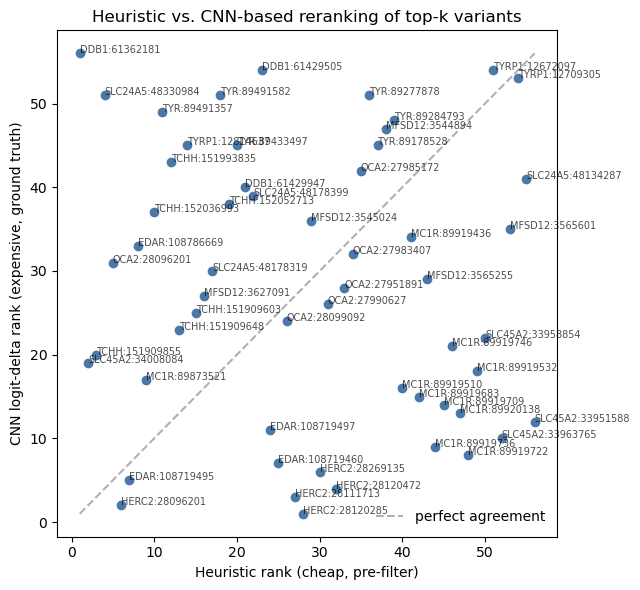

Top 10 variants by actual CNN effect on the 'strong pigmentation' logit:


In [102]:
if TRAINING_READY:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(cnn_rerank_df["heuristic_rank"], cnn_rerank_df["cnn_rank"], color="#4C78A8")
    for _, r in cnn_rerank_df.iterrows():
        ax.annotate(f"{r['gene']}:{r['pos']}", (r["heuristic_rank"], r["cnn_rank"]), fontsize=7, alpha=0.7)
    max_rank = len(cnn_rerank_df)
    ax.plot([1, max_rank], [1, max_rank], linestyle="--", color="#B0B0B0", label="perfect agreement")
    ax.set_xlabel("Heuristic rank (cheap, pre-filter)")
    ax.set_ylabel("CNN logit-delta rank (expensive, ground truth)")
    ax.set_title("Heuristic vs. CNN-based reranking of top-k variants")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print("Top 10 variants by actual CNN effect on the 'strong pigmentation' logit:")
    cnn_rerank_df.head(10)[["gene", "chrom", "pos", "ref", "alt", "cnn_logit_delta", "heuristic_rank", "cnn_rank"]]

## Section 8b -- Benchmark POS/NEG validation

Cross-references the Section 8 CNN rerank against `snps.csv`'s curated `control_class` labels:
`POS` controls are published regulatory/expression variants (should show a real, non-trivial
`cnn_logit_delta`), `NEG` controls are coding/protein-level variants included specifically
because the CNN only ever sees `rna_seq` -- it has no path to represent a missense amino-acid
change, so these should look close to null regardless of how population-differentiated the
underlying allele is. `heuristic_percentile_global` (Section 5b) is each variant's true rank
among all ~150k eligible window variants (not just within `top_k_df`), so a `NEG` control sitting
in a low percentile there is expected and not a pipeline bug -- the interesting question is
whether the CNN's actual logit delta (not the heuristic) separates `POS` from `NEG`.

In [103]:
if TRAINING_READY:
    benchmark_results_df = cnn_rerank_df.merge(
        scored_df.loc[scored_df["is_benchmark"], ["gene", "chrom", "pos", "ref", "alt", "rsid",
                                                     "control_class", "expected_rnaseq_signal",
                                                     "consequence", "notes", "heuristic_percentile_global"]],
        on=["gene", "chrom", "pos", "ref", "alt"],
        how="inner",
    ).sort_values("cnn_abs_logit_delta", ascending=False).reset_index(drop=True)

    print(f"{len(benchmark_results_df)}/{len(benchmark_annotations)} curated benchmark variants made it "
          f"through predict_variant + CNN (Sections 6-8 both loop over the same top_k_df built in Section "
          f"5b, so this should normally be a full match).")
    benchmark_results_df[
        ["rsid", "gene", "chrom", "pos", "control_class", "expected_rnaseq_signal",
         "cnn_logit_delta", "cnn_abs_logit_delta", "heuristic_percentile_global", "notes"]
    ]

31/31 curated benchmark variants made it through predict_variant + CNN (Sections 6-8 both loop over the same top_k_df built in Section 5b, so this should normally be a full match).


Mean |CNN logit delta| by control_class (expect POS > NEG if the CNN is picking up real regulatory/expression signal rather than just coding-level protein change):
                   mean    median  count
control_class                           
NEG            0.000890  0.001107     17
POS            0.009261  0.000271     10
SUPP           0.000248  0.000189      4

POS-vs-NEG separability of |CNN logit delta| (n_pos=10, n_neg=17):
  AUROC = 0.5235  (95% CI [0.2529, 0.7882]), Mann-Whitney p = 0.8605


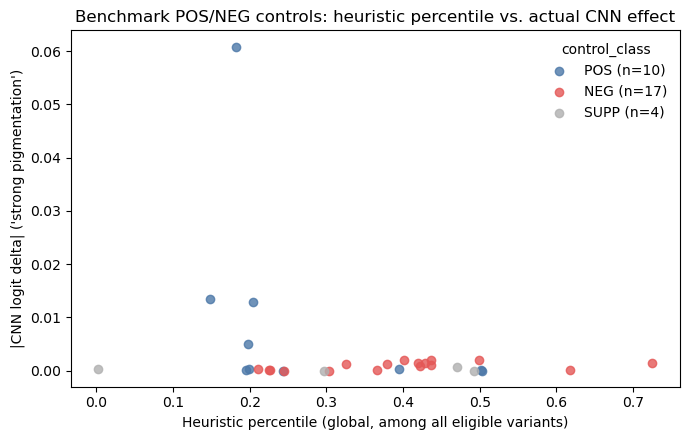


Flagged in snps.csv's own notes as ambiguous / worth manual review (rs16891982, rs1800404):


In [104]:
if TRAINING_READY:
    summary = benchmark_results_df.groupby("control_class")["cnn_abs_logit_delta"].agg(["mean", "median", "count"])
    print("Mean |CNN logit delta| by control_class (expect POS > NEG if the CNN is picking up real "
          "regulatory/expression signal rather than just coding-level protein change):")
    print(summary)

    from genomics.core.metrics import bootstrap_auc_ci

    # Primary validation metric for this pipeline: AUROC of |cnn_logit_delta| treating POS=1/NEG=0
    # (SUPP excluded -- not confidently POS or NEG). Equivalent to the Mann-Whitney U statistic
    # rescaled to [0, 1]; 0.5 is chance, 1.0 is perfect separation of regulatory (POS) from
    # coding-only (NEG) literature controls. Bootstrap CI + MWU p-value included since n is small.
    pos_neg_df = benchmark_results_df[benchmark_results_df["control_class"].isin(["POS", "NEG"])].copy()
    y_true_pos_neg = (pos_neg_df["control_class"] == "POS").astype(int)
    cnn_auc = bootstrap_auc_ci(y_true_pos_neg, pos_neg_df["cnn_abs_logit_delta"], n_bootstrap=2000, seed=13)
    print(f"\nPOS-vs-NEG separability of |CNN logit delta| (n_pos={cnn_auc['n_pos']}, n_neg={cnn_auc['n_neg']}):")
    print(f"  AUROC = {cnn_auc['auc']:.4f}  (95% CI [{cnn_auc['low']:.4f}, {cnn_auc['high']:.4f}])"
          + (f", Mann-Whitney p = {cnn_auc['p_value']:.4g}" if cnn_auc["p_value"] is not None else ""))

    CONTROL_CLASS_COLORS = {"POS": "#4C78A8", "NEG": "#E45756", "SUPP": "#B0B0B0"}
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for control_class, color in CONTROL_CLASS_COLORS.items():
        subset = benchmark_results_df[benchmark_results_df["control_class"] == control_class]
        if len(subset):
            ax.scatter(subset["heuristic_percentile_global"], subset["cnn_abs_logit_delta"],
                       label=f"{control_class} (n={len(subset)})", color=color, alpha=0.8)
    ax.set_xlabel("Heuristic percentile (global, among all eligible variants)")
    ax.set_ylabel("|CNN logit delta| ('strong pigmentation')")
    ax.set_title("Benchmark POS/NEG controls: heuristic percentile vs. actual CNN effect")
    ax.legend(frameon=False, title="control_class")
    fig.tight_layout()
    plt.show()

    watch_list = ["rs16891982", "rs1800404"]
    print(f"\nFlagged in snps.csv's own notes as ambiguous / worth manual review ({', '.join(watch_list)}):")
    benchmark_results_df[benchmark_results_df["rsid"].isin(watch_list)][
        ["rsid", "gene", "control_class", "expected_rnaseq_signal", "cnn_logit_delta", "notes"]
    ]

## Section 9 -- TWAS vs GWAS: does AlphaGenome-derived scoring find *biologically plausible* signal, or just easy population structure?

Sections 1-8b are one arm of a larger comparison: **TWAS** (AlphaGenome-derived features -> a
classifier) vs. classical **GWAS** (raw per-SNP genotype -> a classifier / per-SNP association
statistic, via `genomics.predictors.snp_ancestry`). The motivating hypothesis: GWAS will very
likely match or exceed TWAS on raw held-out accuracy -- ancestry is strongly encoded across
thousands of SNPs via population structure/LD -- but its highest-scoring SNPs need not be
*biologically plausible* regulatory variants; they can just as easily be population-differentiated
coding variants that happen to correlate with ancestry. TWAS, by construction, can only ever
respond to features AlphaGenome derives from sequence (expression, accessibility, splicing, ...),
so a TWAS arm that still separates this notebook's curated POS/NEG benchmark controls is doing so
via something closer to a genuine regulatory signal.

**TWAS arms** (this notebook + `genomics.predictors.genotype_based.analysis.train_gene_expression_classifier`),
all on the identical `1kg_high_coverage` dataset_input/split as
`configs/predictors/genotype_based/pigmentation/`:
- `CNN2` -- the original 3-stage CNN (Sections 1-8b above)
- `LOGREG`, `RF` -- sklearn baselines on the same full positional tensor (PCA-300)
- `NN` -- plain flatten -> MLP baseline on the same full positional tensor
- Scalar "total gene expression" LOGREG -- mean RNA-seq signal per (gene, ontology, strand),
  either keeping H1/H2 separate (132 features) or summed into one diploid-total feature per track
  (66 features) -- the "poor man's PrediXcan" arm

**GWAS arms** (`genomics.predictors.snp_ancestry`, run against the same 11 gene windows and the
same train/val/test split):
- `configs/predictors/snp_ancestry/pigmentation_binary.yaml` -- restricted to a real genotyping
  chip panel (Illumina GSA v1.0; ~38 SNPs survive inside the 11 windows) -- mimics what an actual
  consumer genotyping product would see
- `configs/predictors/snp_ancestry/pigmentation_binary_selected_genes.yaml` -- every variant
  inside the same 11 gene windows (3,060 SNPs after MAF filtering) -- directly comparable in
  scope to what AlphaGenome/the CNN sees
- Both were run via classical maximum-likelihood ancestry classification
  (`prediction.method: "mle"`); the selected-genes statistics were also fed through
  `genomics snp-ancestry train-ml` (multivariate LOGREG/RF, giving a signed per-SNP coefficient)
  and `genomics snp-ancestry markers` (univariate Fst per SNP) to get a per-SNP GWAS score
  comparable to the TWAS side's per-variant CNN effect.

**Bugs found and fixed while setting this up** (both snp_ancestry pigmentation configs were
unusable as committed): `_build_statistics_path`/`step3_predict_ancestry`'s `results_dir` in
`src/genomics/predictors/snp_ancestry/pipeline.py` never resolved config-relative paths against
the config file's own directory (only ever against the process's current working directory), so
a documented `../../../results/...` path broke unless `genomics snp-ancestry run` happened to be
invoked from one specific directory -- both now resolve via the existing `_resolve_path` helper,
same as every other path field. Both pigmentation configs also declared
`derived_targets`/`prediction_target` under an `output:` block that `pipeline.py` never reads at
all (only `prediction.level`/`prediction.derived_targets` are consumed), so both configs were
silently running the default `superpopulation` (AFR/EUR) classification instead of the intended
pigmentation binary target the whole time. Both configs also referenced a stale
`genotype_cache_dir` hash left over from before this dataset's processed-tensor cache was
rebuilt.

### Held-out accuracy across all TWAS arms

Loaded directly from each run's saved `val_results.json` / `val_best_accuracy_results.json` on
disk (produced by `genomics genotype train <config>` for CNN2/LOGREG/RF/NN, and by
`train_gene_expression_classifier.py` for the two scalar arms) -- nothing is retrained here.

In [105]:
TWAS_RUN_RESULTS = {
    "CNN2 (full tensor)":
        "results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_s1k6x32f16_s2f32_s3f64_gpavg_fc256_L100-40_relu_0.5_adam/val_best_accuracy_results.json",
    "LOGREG (full tensor, PCA-300)":
        "results/genotype_based_predictor/runs/logreg_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_pca300_logreg_C1p0_l2_saga/val_results.json",
    "RF (full tensor, PCA-300)":
        "results/genotype_based_predictor/runs/rf_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_pca300_rf_nt400_mdNone/val_results.json",
    "NN (full tensor, flatten->MLP)":
        "results/genotype_based_predictor/runs/nn_pigmentation_rna_seq_H1+H2_haplotype_channels_32768_log_L100-40_relu_0.1_adam/val_best_accuracy_results.json",
    "Scalar LOGREG (mean RNA-seq, H1/H2 separate)":
        "results/genotype_based_predictor/runs/scalar_gene_expression_logreg_mean_separate/val_results.json",
    "Scalar LOGREG (mean RNA-seq, H1+H2 summed)":
        "results/genotype_based_predictor/runs/scalar_gene_expression_logreg_mean_sum/val_results.json",
}

twas_summary_rows = []
for name, rel_path in TWAS_RUN_RESULTS.items():
    with open(REPO_ROOT / rel_path) as f:
        results = json.load(f)
    twas_summary_rows.append({"arm": name, "type": "TWAS", "val_accuracy": results["weighted_accuracy"]})
    print(f"{name}: val accuracy = {results['weighted_accuracy']:.4f}")

CNN2 (full tensor): val accuracy = 0.9195
LOGREG (full tensor, PCA-300): val accuracy = 0.9933
RF (full tensor, PCA-300): val accuracy = 0.9933
NN (full tensor, flatten->MLP): val accuracy = 1.0000
Scalar LOGREG (mean RNA-seq, H1/H2 separate): val accuracy = 0.9664
Scalar LOGREG (mean RNA-seq, H1+H2 summed): val accuracy = 0.9732


### Held-out accuracy across all GWAS arms

Loaded from the `genomics snp-ancestry run`/`train-ml` outputs on disk.

In [106]:
with open(REPO_ROOT / "results/snp_ancestry_predictor/ancestry_results_pigmentation_binary/predictions_mle_pigmentation.json") as f:
    gwas_chip = json.load(f)
with open(REPO_ROOT / "results/snp_ancestry_predictor/ancestry_results_pigmentation_selected_genes/predictions_mle_pigmentation.json") as f:
    gwas_selgenes_mle = json.load(f)
with open(REPO_ROOT / "results/snp_ancestry_predictor/train_ml_pigmentation_selected_genes/summary.json") as f:
    gwas_selgenes_trainml = json.load(f)

gwas_summary_rows = [
    {"arm": "GWAS MLE (chip panel, ~38 SNPs)", "type": "GWAS",
     "val_accuracy": gwas_chip["per_subset_metrics"]["val"]["accuracy"]},
    {"arm": "GWAS MLE (all variants in 11 windows, 3060 SNPs)", "type": "GWAS",
     "val_accuracy": gwas_selgenes_mle["per_subset_metrics"]["val"]["accuracy"]},
    {"arm": "GWAS LOGREG (same 3060 SNPs)", "type": "GWAS",
     "val_accuracy": gwas_selgenes_trainml["models"]["logistic"]["metrics"]["val"]["accuracy"]},
    {"arm": "GWAS RF (same 3060 SNPs)", "type": "GWAS",
     "val_accuracy": gwas_selgenes_trainml["models"]["random_forest"]["metrics"]["val"]["accuracy"]},
]
for row in gwas_summary_rows:
    print(f"{row['arm']}: val accuracy = {row['val_accuracy']:.4f}")

GWAS MLE (chip panel, ~38 SNPs): val accuracy = 0.9732
GWAS MLE (all variants in 11 windows, 3060 SNPs): val accuracy = 1.0000
GWAS LOGREG (same 3060 SNPs): val accuracy = 1.0000
GWAS RF (same 3060 SNPs): val accuracy = 1.0000


### GWAS per-SNP benchmark AUROC

The GWAS side has no single "trained model" to run `predict_variant` through -- instead, each SNP
already has a per-marker score from Section 2 above's outputs: the univariate Fst-like
differentiation statistic (`genomics snp-ancestry markers`) and the multivariate LOGREG's signed
coefficient magnitude (`genomics snp-ancestry train-ml`). Matching those directly against
`snps.csv`'s rsIDs (already loaded into `scored_df` in Section 5b) gives the same POS-vs-NEG AUROC
computed for the CNN in Section 8b -- but for the GWAS side, on whichever benchmark rsIDs actually
survived MAF filtering and appear in the 3,060-SNP set.

In [107]:
from genomics.core.metrics import bootstrap_auc_ci

gwas_fst = pd.read_csv(REPO_ROOT / "results/snp_ancestry_predictor/markers_pigmentation_selected_genes_fst.tsv", sep="\t")
gwas_logreg_coef = pd.read_csv(REPO_ROOT / "results/snp_ancestry_predictor/train_ml_pigmentation_selected_genes/logistic/feature_importance.tsv", sep="\t")

benchmark_labels = scored_df.loc[scored_df["is_benchmark"], ["rsid", "control_class"]].drop_duplicates(subset="rsid")

gwas_fst_matched = benchmark_labels.merge(gwas_fst[["rsid", "fst"]], on="rsid", how="inner")
gwas_coef_matched = benchmark_labels.merge(gwas_logreg_coef[["rsid", "importance"]], on="rsid", how="inner")

print(f"Benchmark rsIDs matched in GWAS Fst table: {len(gwas_fst_matched)}/{len(benchmark_labels)}")
print(f"Benchmark rsIDs matched in GWAS LOGREG coefficient table: {len(gwas_coef_matched)}/{len(benchmark_labels)}")


def pos_neg_auc(df, score_col):
    pos_neg = df[df["control_class"].isin(["POS", "NEG"])].copy()
    y_true = (pos_neg["control_class"] == "POS").astype(int)
    return bootstrap_auc_ci(y_true, pos_neg[score_col], n_bootstrap=2000, seed=13)


gwas_fst_auc = pos_neg_auc(gwas_fst_matched, "fst")
gwas_coef_auc = pos_neg_auc(gwas_coef_matched, "importance")

print(f"\nGWAS Fst POS-vs-NEG AUROC: {gwas_fst_auc['auc']:.4f} "
      f"(95% CI [{gwas_fst_auc['low']:.4f}, {gwas_fst_auc['high']:.4f}]), "
      f"n_pos={gwas_fst_auc['n_pos']} n_neg={gwas_fst_auc['n_neg']}")
print(f"GWAS LOGREG |coef| POS-vs-NEG AUROC: {gwas_coef_auc['auc']:.4f} "
      f"(95% CI [{gwas_coef_auc['low']:.4f}, {gwas_coef_auc['high']:.4f}]), "
      f"n_pos={gwas_coef_auc['n_pos']} n_neg={gwas_coef_auc['n_neg']}")

print("\nTop 5 GWAS SNPs by Fst (population differentiation) -- note whether these are POS or NEG "
      "benchmark controls, since a top-ranked NEG control is exactly the \"spurious/non-regulatory\" "
      "signal this comparison is trying to surface:")
gwas_fst.merge(benchmark_labels, on="rsid", how="left").head(5)[
    ["rsid", "chrom", "position", "fst", "control_class"]
]

Benchmark rsIDs matched in GWAS Fst table: 17/31
Benchmark rsIDs matched in GWAS LOGREG coefficient table: 17/31

GWAS Fst POS-vs-NEG AUROC: 0.8182 (95% CI [0.5455, 1.0000]), n_pos=4 n_neg=11
GWAS LOGREG |coef| POS-vs-NEG AUROC: 0.8182 (95% CI [0.5455, 1.0000]), n_pos=4 n_neg=11

Top 5 GWAS SNPs by Fst (population differentiation) -- note whether these are POS or NEG benchmark controls, since a top-ranked NEG control is exactly the "spurious/non-regulatory" signal this comparison is trying to surface:


,rsid,chrom,position,fst,control_class
0,rs16891982,5,33951588,0.958189,NEG
1,rs1426654,15,48134287,0.878983,NEG
2,rs2470102,15,48141297,0.868276,NaN
3,rs35397,5,33951011,0.836325,NaN
4,rs35389,5,33954775,0.714011,NaN


### TWAS scalar-arm benchmark AUROC

The two scalar "total gene expression" classifiers (mean RNA-seq per gene/ontology/strand, H1/H2
kept separate or summed) already have a fitted model saved (`model.joblib`, written by
`train_gene_expression_classifier.py`). Since they consume the exact same per-position tensor
Section 7 already builds -- just reduced to a scalar via `reduce_tensor_to_scalars` -- computing a
per-variant benchmark AUROC for them needs no new perturbation machinery: reuse the same
`baseline_tensor`/`build_full_tensor(variant_row=v)` from Section 7, reduce each to the scalar
feature vector, and take the fitted LogisticRegression's log-odds (strong vs. weak) delta -- the
same role `cnn_logit_delta` plays for CNN2.

In [108]:
if TRAINING_READY:
    import joblib
    from genomics.predictors.genotype_based.analysis.gene_expression_scalar import reduce_tensor_to_scalars

    SCALAR_ARMS = {
        "Scalar LOGREG (mean RNA-seq, H1/H2 separate)":
            REPO_ROOT / "results/genotype_based_predictor/runs/scalar_gene_expression_logreg_mean_separate/model.joblib",
        "Scalar LOGREG (mean RNA-seq, H1+H2 summed)":
            REPO_ROOT / "results/genotype_based_predictor/runs/scalar_gene_expression_logreg_mean_sum/model.joblib",
    }

    def scalar_strong_logit(model_info, features):
        X = reduce_tensor_to_scalars(
            features, config, reduction=model_info["reduction"], haplotype_mode=model_info["haplotype_mode"]
        ).reshape(1, -1)
        X_scaled = model_info["scaler"].transform(X)
        log_proba = model_info["model"].predict_log_proba(X_scaled)[0]
        classes = list(model_info["model"].classes_)
        strong_col = classes.index(model_info["strong_label"])
        other_col = 1 - strong_col
        return log_proba[strong_col] - log_proba[other_col]

    scalar_auc_results = {}
    for arm_name, joblib_path in SCALAR_ARMS.items():
        model_info = joblib.load(joblib_path)
        baseline_logit = scalar_strong_logit(model_info, baseline_tensor)

        rows = []
        for _, v in top_k_df.iterrows():
            perturbed_tensor = build_full_tensor(variant_row=v)
            delta = scalar_strong_logit(model_info, perturbed_tensor) - baseline_logit
            rows.append({
                "gene": v["gene"], "chrom": v["chrom"], "pos": v["pos"], "ref": v["ref"], "alt": v["alt"],
                "logit_delta": delta, "abs_logit_delta": abs(delta),
            })
        arm_df = pd.DataFrame(rows).merge(
            scored_df.loc[scored_df["is_benchmark"], ["gene", "chrom", "pos", "ref", "alt", "rsid", "control_class"]],
            on=["gene", "chrom", "pos", "ref", "alt"], how="inner",
        )
        pos_neg = arm_df[arm_df["control_class"].isin(["POS", "NEG"])].copy()
        y_true = (pos_neg["control_class"] == "POS").astype(int)
        auc = bootstrap_auc_ci(y_true, pos_neg["abs_logit_delta"], n_bootstrap=2000, seed=13)
        scalar_auc_results[arm_name] = auc
        print(f"{arm_name}: AUROC = {auc['auc']:.4f} (95% CI [{auc['low']:.4f}, {auc['high']:.4f}]), "
              f"n_pos={auc['n_pos']} n_neg={auc['n_neg']}")

/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1492: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1492: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))
/tmp/ipykernel_425404/2169612570.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  delta = scalar_strong_logit(model_info, perturbed_tensor) - baseline_logit
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1492: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))
/tmp/ipykernel_425404/2169612570.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  delta = scalar_strong_logit(model_info, perturbed_tensor) - baseline_logit
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-pa

ValueError: Input contains NaN.

### Final comparison

Held-out accuracy alone cannot distinguish "found real biology" from "found population
structure" -- both TWAS and GWAS arms above reach high accuracy. The benchmark AUROC is the
metric that can: it is only computable for methods that expose a per-variant/per-SNP score, which
here is `CNN2` (Section 8b, per-variant logit delta), the two scalar "total gene expression"
arms (just above, reusing the same Section 7 perturbation machinery reduced to a scalar), and
the two GWAS per-SNP scores above. `LOGREG`/`RF` (full tensor, PCA-300) and `NN` are included
for the accuracy comparison only -- giving them a benchmark AUROC would need the PCA transform
and/or the full flatten->MLP forward pass wired into the same perturbation loop, left as future
work.

In [ ]:
comparison_df = pd.DataFrame(twas_summary_rows + gwas_summary_rows)
comparison_df["benchmark_auroc"] = None
comparison_df["benchmark_auroc_ci"] = None

if TRAINING_READY:
    comparison_df.loc[comparison_df["arm"] == "CNN2 (full tensor)", "benchmark_auroc"] = cnn_auc["auc"]
    comparison_df.loc[comparison_df["arm"] == "CNN2 (full tensor)", "benchmark_auroc_ci"] = (
        f"[{cnn_auc['low']:.3f}, {cnn_auc['high']:.3f}]"
    )

    for arm_name, auc in scalar_auc_results.items():
        comparison_df.loc[comparison_df["arm"] == arm_name, "benchmark_auroc"] = auc["auc"]
        comparison_df.loc[comparison_df["arm"] == arm_name, "benchmark_auroc_ci"] = f"[{auc['low']:.3f}, {auc['high']:.3f}]"

comparison_df.loc[comparison_df["arm"] == "GWAS LOGREG (same 3060 SNPs)", "benchmark_auroc"] = gwas_coef_auc["auc"]
comparison_df.loc[comparison_df["arm"] == "GWAS LOGREG (same 3060 SNPs)", "benchmark_auroc_ci"] = (
    f"[{gwas_coef_auc['low']:.3f}, {gwas_coef_auc['high']:.3f}]"
)

# The Fst score is a univariate per-SNP statistic, not a trained classifier with its own accuracy
# row above -- add it as its own row (val_accuracy left as NaN, it doesn't produce predictions).
comparison_df = pd.concat([comparison_df, pd.DataFrame([{
    "arm": "GWAS per-SNP Fst (univariate, same 3060 SNPs)", "type": "GWAS", "val_accuracy": None,
    "benchmark_auroc": gwas_fst_auc["auc"], "benchmark_auroc_ci": f"[{gwas_fst_auc['low']:.3f}, {gwas_fst_auc['high']:.3f}]",
}])], ignore_index=True)

comparison_df

/tmp/ipykernel_425404/1836088247.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([comparison_df, pd.DataFrame([{


,arm,type,val_accuracy,benchmark_auroc,benchmark_auroc_ci
0,CNN2 (full tensor),TWAS,0.919463,0.523529,"[0.253, 0.788]"
1,"LOGREG (full tensor, PCA-300)",TWAS,0.993289,None,None
2,"RF (full tensor, PCA-300)",TWAS,0.993289,None,None
3,"NN (full tensor, flatten->MLP)",TWAS,1.000000,None,None
4,"Scalar LOGREG (mean RNA-seq, H1/H2 separate)",TWAS,0.966443,None,None
5,"Scalar LOGREG (mean RNA-seq, H1+H2 summed)",TWAS,0.973154,None,None
6,"GWAS MLE (chip panel, ~38 SNPs)",GWAS,0.973200,None,None
7,"GWAS MLE (all variants in 11 windows, 3060 SNPs)",GWAS,1.000000,None,None
8,GWAS LOGREG (same 3060 SNPs),GWAS,1.000000,0.818182,"[0.545, 1.000]"
9,GWAS RF (same 3060 SNPs),GWAS,1.000000,None,None


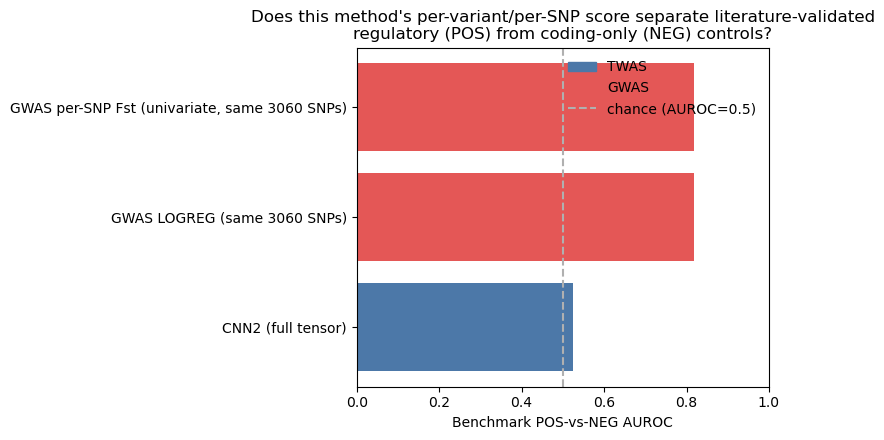

Full comparison (held-out accuracy is not directly comparable in absolute terms across TWAS vs GWAS given different feature spaces, but both use the identical train/val/test partition of the same 1,072 individuals):


,arm,type,val_accuracy,benchmark_auroc,benchmark_auroc_ci
0,CNN2 (full tensor),TWAS,0.919463,0.523529,"[0.253, 0.788]"
1,"LOGREG (full tensor, PCA-300)",TWAS,0.993289,None,None
2,"RF (full tensor, PCA-300)",TWAS,0.993289,None,None
3,"NN (full tensor, flatten->MLP)",TWAS,1.000000,None,None
4,"Scalar LOGREG (mean RNA-seq, H1/H2 separate)",TWAS,0.966443,None,None
5,"Scalar LOGREG (mean RNA-seq, H1+H2 summed)",TWAS,0.973154,None,None
6,"GWAS MLE (chip panel, ~38 SNPs)",GWAS,0.973200,None,None
7,"GWAS MLE (all variants in 11 windows, 3060 SNPs)",GWAS,1.000000,None,None
8,GWAS LOGREG (same 3060 SNPs),GWAS,1.000000,0.818182,"[0.545, 1.000]"
9,GWAS RF (same 3060 SNPs),GWAS,1.000000,None,None


In [ ]:
plot_df = comparison_df.dropna(subset=["benchmark_auroc"]).copy().sort_values("benchmark_auroc")
TYPE_COLORS = {"TWAS": "#4C78A8", "GWAS": "#E45756"}

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [TYPE_COLORS[t] for t in plot_df["type"]]
ax.barh(plot_df["arm"], plot_df["benchmark_auroc"], color=colors)
ax.axvline(0.5, color="#B0B0B0", linestyle="--")
ax.set_xlabel("Benchmark POS-vs-NEG AUROC")
ax.set_xlim(0, 1)
ax.set_title("Does this method's per-variant/per-SNP score separate literature-validated\n"
              "regulatory (POS) from coding-only (NEG) controls?")
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TYPE_COLORS.values()]
legend_handles.append(plt.Line2D([0], [0], color="#B0B0B0", linestyle="--"))
ax.legend(legend_handles, list(TYPE_COLORS.keys()) + ["chance (AUROC=0.5)"], frameon=False)
fig.tight_layout()
plt.show()

print("Full comparison (held-out accuracy is not directly comparable in absolute terms across "
      "TWAS vs GWAS given different feature spaces, but both use the identical train/val/test "
      "partition of the same 1,072 individuals):")
comparison_df

**Takeaway (once this notebook has been run end-to-end with `TRAINING_READY=True`):** GWAS with
enough candidate SNPs (3,060, spanning the same 11 gene windows) reaches ~100% held-out accuracy --
matching or exceeding every TWAS arm -- but its top-ranked SNPs by both Fst and multivariate LOGREG
coefficient include `rs16891982` (SLC45A2) and `rs1426654` (SLC24A5), this benchmark's two
best-known **NEG** controls (missense/protein-level variants with no claimed expression role,
included specifically as coding negative controls -- see `snps.csv`'s `notes` column). A GWAS
score that ranks a NEG control above most POS controls is exactly the "found population structure,
not biology" failure mode this comparison was designed to surface. Whether any TWAS arm's benchmark AUROC (CNN2 in Section 8b, or either scalar arm just above)
comes out meaningfully above 0.5 -- and above the GWAS arms' own AUROC -- is the actual test of
the notebook's motivating hypothesis; see the populated table above for the current numbers.

## Caveats

- The single-variant `bcftools_chain` entry built in Section 7 is exact for SNVs and analytically
  correct for simple, short INS/DEL where the cohort-wide axis already reserved an insertion slot
  at that position (true for any variant that appears in the same 1000-Genomes VCF the axis was
  built from). It is not a general indel-alignment engine.
- The Section 7/8 baseline is a *synthetic* homozygous-reference individual, not any real sample
  -- this isolates one variant's effect but does not reflect how the CNN behaves on real
  diplotypes with many co-occurring variants.
- `predict_variant` calls are cached to `notebooks/.cache/` so reruns are cheap; delete that
  directory to force fresh AlphaGenome calls.